<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer supported. Adjust the input and output path if needed.

In [1]:
from __future__ import annotations

# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

# Plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import seaborn as sns

# TF-IDf
from sklearn.feature_extraction.text import TfidfTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# import torch

# Graphs
%env NX_CUGRAPH_AUTOCONFIG=True  # Enable cuGraph as the gpu-accelerated backend for NetworkX 
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable
from tqdm import tqdm
import re
from datetime import date
from typing import List

env: NX_CUGRAPH_AUTOCONFIG=True  # Enable cuGraph as the gpu-accelerated backend for NetworkX


# Parameters

In [2]:
# Path to data
# Recommended: working directory is: "Backbone-Graph/src"
dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")


# Flags to control execution
run_demo = True  # Controls the demo functions until the Parameter Sweep section
run_parameter_sweep_analysis = False  # Controls the Parameter Sweep: Information Gain Analysis section


# columns' names
account_id_col = "accountid"
author_key_score_col = "topic_author_key_score"

# parametres
topic_col = "BERTopic_topic_256"
top_percentage = 0.01 # percentage of top authors to select as key\boost authors.
entity_cols_lst = ["hashtags", "account_mentions", "ner_entities"] # no "urls"

# Loading and Exporting

## Load Data

In [ ]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../experimental_results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
df_input_path = processed_dataset_path / f"processed_{file_name}"
print(f"Running on local/cluster.\nLoading data from: {df_input_path}")

# Load the parquet file
df = pd.read_parquet(df_input_path)

df[account_id_col] = df[account_id_col].astype(str)
print(f"In the df casted {account_id_col} to str")

# for testing
# df = df.sample(n = 500).reset_index(drop=True)  # TODO delete after debugging.

Running on local/cluster.
Loading data from: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet
In the df casted accountid to str


## Output

In [4]:
folder_output_path = processed_dataset_path / date.today().strftime("%Y_%m_%d")
folder_output_path.mkdir(parents=True, exist_ok=True)
print(f"Output will be saved to: {folder_output_path}")

Output will be saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30


# Logs

In [5]:
from functools import wraps
from datetime import datetime



REPORT_PATH = folder_output_path / "progress_report.txt"

def write_report(msg: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"{timestamp} | {msg}"

    print(line)
    with open(REPORT_PATH, "a") as f:
        f.write(line + "\n")


def report_done(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as e:
            write_report(f"FAILED: {func.__name__} | {e}")
            write_report("#######################################################")
            write_report("#######################################################")
            raise
    return wrapper

In [6]:
write_report("Starting new execution of key_authors_graph.ipynb")
write_report(f"df path: {df_input_path}")
write_report(f"df with {len(df):,} rows and {len(df.columns):,} columns")
write_report(f"Output path: {folder_output_path}")

2026-04-30 11:29:14 | Starting new execution of key_authors_graph.ipynb
2026-04-30 11:29:14 | df path: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet
2026-04-30 11:29:14 | df with 1,468,565 rows and 37 columns
2026-04-30 11:29:14 | Output path: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30


# Save df

In [7]:
def save_df(df, folder_output_path, file_name):
    df_output_path = folder_output_path / f"processed_{file_name}"
    df.to_parquet(df_output_path, index=False, compression="gzip")
    write_report(f"df is saved to: {df_output_path}")

# Statistics

## Dataset Collums

In [8]:
print(f"df shape: ({df.shape[0]:,}, {df.shape[1]:,})")
print(f"Number of posts: {df.shape[0]:,}")
print(f"Number of unique authors: {df[account_id_col].nunique():,}")

print("")
print(f"{'**column name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shape: (1,468,565, 37)
Number of posts: 1,468,565
Number of unique authors: 21,923

**column name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic_512          

## Topics Distribution

In [9]:
def extract_number(col_name: str) -> int:
    """Extract first integer found in column name.
    
    Args:
        col_name: Column name string.
        
    Returns:
        int: Extracted number or -1 if none found.
    """
    match = re.search(r"\d+", col_name)
    return int(match.group()) if match else -1

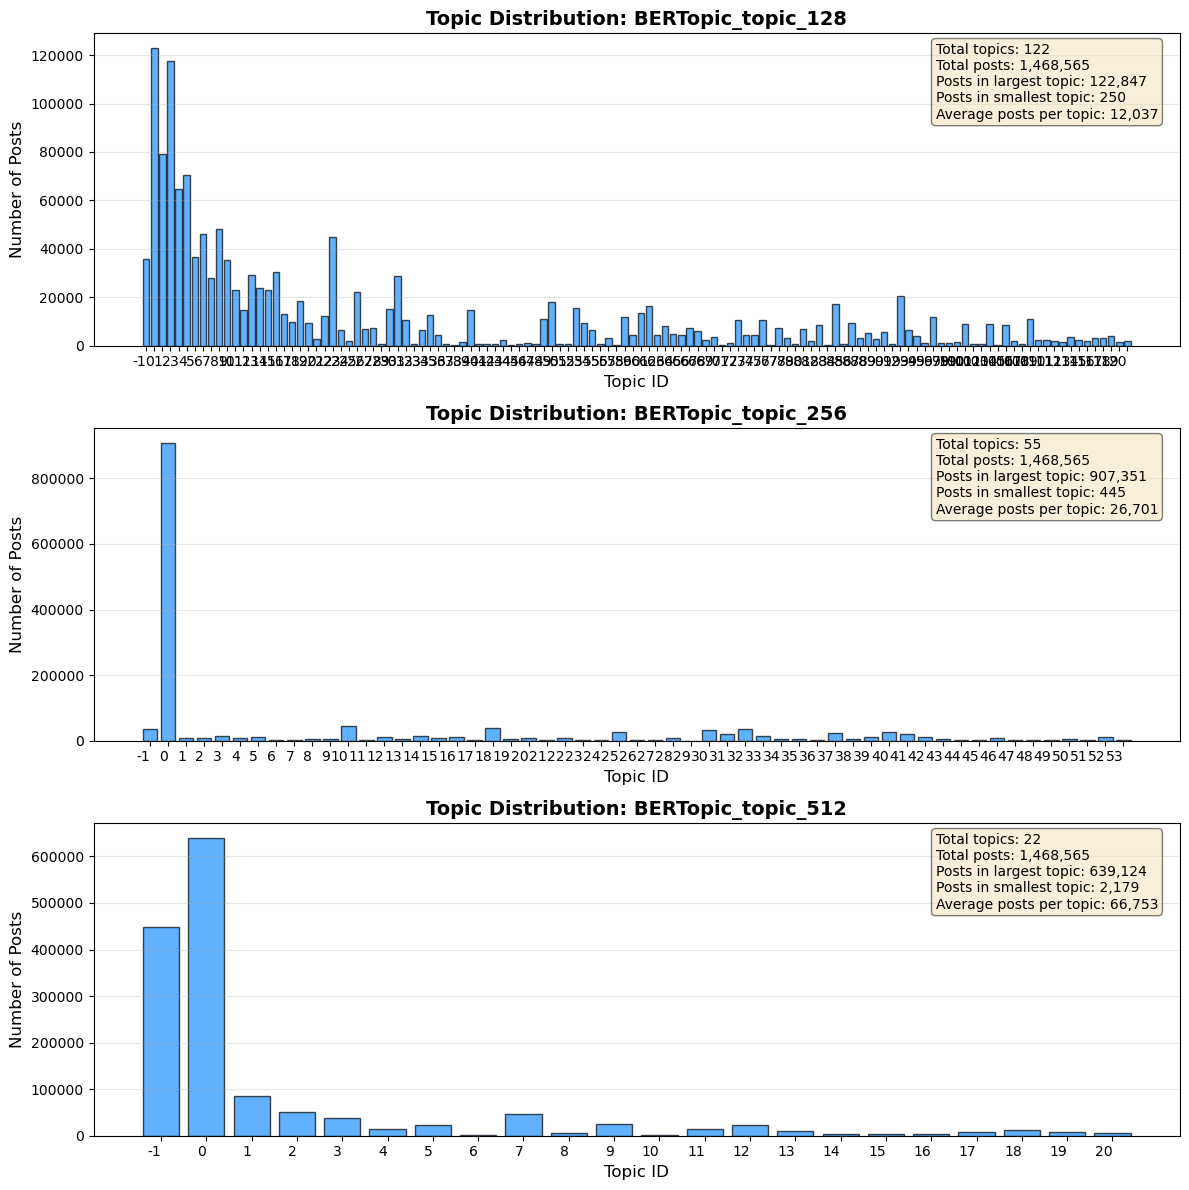

In [10]:
# Find all columns with "BERT", "K_Means", or "topic" in the name (excluding "prob" columns)
topic_columns = [
    col for col in df.columns 
    if any(keyword.lower() in col.lower() for keyword in ["BERT", "K_Means", "topic"])
    and "prob" not in col.lower()
]
topic_columns = sorted(topic_columns, key=extract_number)

# Create distribution plots for each topic column
num_cols = len(topic_columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))

# Handle case where there's only one column (axes won't be an array)
if num_cols == 1:
    axes = [axes]

for idx, col in enumerate(topic_columns):
    # Count posts per topic
    topic_counts = df[col].value_counts().sort_index()
    
    # Create bar plot
    axes[idx].bar(topic_counts.index, topic_counts.values, color='dodgerblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Topic Distribution: {col}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Topic ID", fontsize=12)
    axes[idx].set_ylabel("Number of Posts", fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Set x-ticks to show all topic IDs
    axes[idx].set_xticks(topic_counts.index)
    axes[idx].set_xticklabels(topic_counts.index, rotation=0, ha='right')
    
    # Add count information
    topic_counts = df[col].value_counts()
    axes[idx].text(
        0.98, 0.97,
        f"Total topics: {len(topic_counts)}\n"
        f"Total posts: {len(df):,}\n"
        f"Posts in largest topic: {topic_counts.max():,}\n"
        f"Posts in smallest topic: {topic_counts.min():,}\n"
        f"Average posts per topic: {topic_counts.mean():,.0f}",
        transform=axes[idx].transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        multialignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()

plt.savefig(folder_output_path / f"topic_distributions.png", dpi=300)
plt.show()
plt.close()

# TF-IDF Score

## Entities

TF-IDF Using *sklearn*

In [11]:
def normalize_entity(x: str) -> str:
    """Normalize a single entity string."""
    return re.sub(r"\s+", "_", str(x).lower().strip())


def normalize_entity_list(lst: Iterable[str]) -> List[str]:
    """Normalize a list of entity strings.

    Args:
        lst: Iterable of entity strings.

    Returns:
        List of normalized entity strings.
    """

    if isinstance(lst, str) or not isinstance(lst, list):
        raise TypeError(f"Expected a list of entities, got: {type(lst)} | value: {lst}")

    return [normalize_entity(x) for x in lst]

In [12]:
@report_done
def compute_entities_tfidf(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str = "BERTopic_topic",
) -> pd.DataFrame:
    """Compute entity TF-IDF by topic.

    This implementation avoids constructing large text documents,
    resulting in faster execution and lower memory usage.

    Args:
        df: Input DataFrame with topic labels and entity lists.
        entity_col: Column containing list-like entities per post.
        topic_col: Topic label column.

    Returns:
        DataFrame with rows=entities, columns=topics, values=tf-idf scores.
    """
    print(f"[compute_entities_tfidf] Topic column: {topic_col}, Entity column: {entity_col}")

    # # Normalize entities in the df (disabled since in parallel processing this is not the same df. this is done in compute_post_tfidf)
    # print(f"[compute_entities_tfidf] Normalizing entities in {entity_col} column.")
    # df[entity_col] = df[entity_col].map(
    #     lambda lst: [normalize_entity(x) for x in lst] if isinstance(lst, list) else lst
    # )

    # Explode to (topic, entity) pairs, drop rows with no entities
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .reset_index(drop=True)
    )

    # Sparse count matrix: rows=topics, cols=entities, values=counts
    topic_entity_counts = pd.crosstab(
        df_exp[topic_col].to_numpy(),
        df_exp[entity_col].to_numpy(),
    )

    print(f"[compute_entities_tfidf] Topic-Entity count matrix shape: {topic_entity_counts.shape}")

    # Apply TF-IDF on the counts
    X_tfidf = TfidfTransformer().fit_transform(topic_entity_counts)

    # Build DataFrame where rows=entities, columns=topics, values=tf-idf scores
    entity_topic_df = pd.DataFrame.sparse.from_spmatrix(
        X_tfidf.T,
        index=topic_entity_counts.columns,
        columns=topic_entity_counts.index,
    )

    return entity_topic_df

In [13]:
if run_demo:
    hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col=topic_col)
    hashtags_tfidf_df.head()

[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: hashtags
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 164846)
2026-04-30 11:29:21 | Completed: compute_entities_tfidf


In [14]:
@report_done
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids, values = TF-IDF scores.
        topic_id (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [15]:
if run_demo:
    topic_id = hashtags_tfidf_df.columns[2]  # example topic id, adjust as needed
    print(f"Top entities for topic {topic_id}:")
    top_entities = get_top_entities(hashtags_tfidf_df, topic_id = topic_id, top_n=10)
    print(top_entities)

Top entities for topic 1:
2026-04-30 11:29:21 | Completed: get_top_entities
['PREMIOSMTVMIAW', 'MTVINSTAARVIGNA', 'MTVINSTAARVICICONTE', 'MTVExPopLali', 'MTVCRUSHREYES', 'MTVEXPOPREYES', 'MTVHITCNCO', 'MTVINSTAMXDANNA', 'MTVEXPOPCNCO', 'MTVACTAPPCNCO']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [16]:
import os

def _compute_one_entity_col_scores(
    df: pd.DataFrame,
    topic_col: str,
    entity_col: str,
) -> np.ndarray:
    """Compute per-row TF-IDF contribution for one entity column.

    Uses explode + merge + groupby and keeps only non-zero TF-IDF values.

    Args:
        df: Input DataFrame with topic and entity-list columns.
        topic_col: Topic column name.
        entity_col: Entity-list column name.

    Returns:
        Numpy array of per-row scores for this entity column.
    """

    pid = os.getpid()
    print(f"[_compute_one_entity_col_scores] PID {pid}: Calculating scores for {entity_col}")

    # Keep only needed columns.
    df_local = df[[topic_col, entity_col]].copy()

    # TF-IDF table: rows=entities, columns=topics, values=tf-idf
    entities_tfidf_df = compute_entities_tfidf(df_local, entity_col, topic_col)

    print(f"[_compute_one_entity_col_scores] PID {pid}: exploding + merging {entity_col}")

    # Convert sparse DataFrame to long table of non-zero scores only.
    coo = entities_tfidf_df.sparse.to_coo()
    scores_long = pd.DataFrame(
        {
            entity_col: entities_tfidf_df.index.to_numpy()[coo.row], # entities_tfidf_df contains the names, coo.row is the indexes for non-zero values
            topic_col: entities_tfidf_df.columns.to_numpy()[coo.col],
            "score": coo.data,
        }
    )

    # One row per original row/entity pair.
    exploded = (
        # reset_index put the original row ids in "row_id" column.
        df_local.reset_index(names="row_id")
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .reset_index(drop=True)
    )

    merged = exploded.merge(
        scores_long,
        on=[entity_col, topic_col],
        how="left",
    )

    # row_scores.index is the original row ids.
    # In sum() Nam=0 so missing matches mean score 0.
    row_scores = merged.groupby("row_id", sort=False)["score"].sum()

    col_scores = np.zeros(len(df_local), dtype=float)
    col_scores[row_scores.index.to_numpy()] = row_scores.to_numpy() 

    print(f"[_compute_one_entity_col_scores] PID {pid}: done {entity_col}")
    return col_scores

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import os

@report_done
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    post_score_col: str = "post_tfidf",
    max_workers: int | None = None,
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns in parallel.

    Updates df[post_score_col] in place.

    Args:
        df: Input DataFrame.
        topic_col: Topic column name.
        entity_cols_lst: Entity-list column names.
        post_score_col: Output score column name.
        max_workers: Number of worker processes.

    Returns:
        None.
    """
    print(
        f"[compute_post_tfidf] Topic column: {topic_col}, "
        f"Entity columns: {entity_cols_lst}\n"
    )


    # normalize entities in all entity columns before parallel processing
    for ent_col in entity_cols_lst:
        print(f"[compute_post_tfidf] Normalizing entities in {ent_col} column.")
        df[ent_col] = df[ent_col].map(
            lambda lst: [normalize_entity(x) for x in lst] if isinstance(lst, list) else lst
        )

    
    # parameters for parallel processing
    min_df_list = [df[[ent_col, topic_col]].copy() for ent_col in entity_cols_lst]
    if max_workers is None:
        max_workers=min(len(entity_cols_lst), os.cpu_count() or 1)
        
    # parallel processing
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        print(f"[compute_post_tfidf] Computing TF-IDF scores for each entity column in parallel with {max_workers} workers...")
        results = list(
            tqdm(
                executor.map(
                    _compute_one_entity_col_scores,
                    min_df_list,
                    [topic_col] * len(entity_cols_lst),
                    entity_cols_lst,
                ),
                total=len(entity_cols_lst),
                desc="[compute_post_tfidf] Entity columns",
            )
        )
    

    print("[compute_post_tfidf] Combining scores from all entity columns...")
    total_scores = np.zeros(len(df), dtype=float)
    for col_scores in results:
        total_scores += col_scores

    df[post_score_col] = total_scores

In [18]:
if run_demo:
    compute_post_tfidf(df, topic_col, entity_cols_lst)
    print(f"### Finished [compute_post_tfidf] ###")
    display(df[["post_text", "post_tfidf", topic_col]].head())

[compute_post_tfidf] Topic column: BERTopic_topic_256, Entity columns: ['hashtags', 'account_mentions', 'ner_entities']

[compute_post_tfidf] Normalizing entities in hashtags column.
[compute_post_tfidf] Normalizing entities in account_mentions column.
[compute_post_tfidf] Normalizing entities in ner_entities column.


[compute_post_tfidf] Entity columns:   0%|          | 0/3 [00:00<?, ?it/s]

[_compute_one_entity_col_scores] PID 2699017: Calculating scores for hashtags
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: hashtags
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 164846)
2026-04-30 11:29:37 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2699017: exploding + merging hashtags
[_compute_one_entity_col_scores] PID 2699017: done hashtags


[compute_post_tfidf] Entity columns:  33%|███▎      | 1/3 [00:08<00:17,  8.63s/it]

[_compute_one_entity_col_scores] PID 2699021: Calculating scores for account_mentions
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: account_mentions
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 271772)
2026-04-30 11:29:48 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2699021: exploding + merging account_mentions
[_compute_one_entity_col_scores] PID 2699021: done account_mentions


[compute_post_tfidf] Entity columns:  67%|██████▋   | 2/3 [00:20<00:10, 10.33s/it]

[_compute_one_entity_col_scores] PID 2699023: Calculating scores for ner_entities
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: ner_entities
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 169685)
2026-04-30 11:29:54 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2699023: exploding + merging ner_entities
[_compute_one_entity_col_scores] PID 2699023: done ner_entities


[compute_post_tfidf] Entity columns: 100%|██████████| 3/3 [00:25<00:00,  8.40s/it]


[compute_post_tfidf] Combining scores from all entity columns...
2026-04-30 11:29:55 | Completed: compute_post_tfidf
### Finished [compute_post_tfidf] ###


,post_text,post_tfidf,BERTopic_topic_256
0,Vamos a cambiar la forma de hacer comunicación...,0.000000,0
1,"Damos servicio de manejo de prensa, elaboració...",0.000000,0
2,@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bu...,0.001447,0
3,"Mario, debemos denuciar que en los poderes pub...",0.021874,0
4,Tambien debemos estar claro que la oposición e...,0.000000,0


In [19]:
if run_demo:
    save_df(df, folder_output_path, file_name)

2026-04-30 11:31:00 | df is saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/processed_Ecuador_part_all.gzip.parquet


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [ ]:
@report_done
def compute_author_key_score(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    author_score_col: str = "topic_author_key_score",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
    folder_output_path: Path = None,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.
    IDF is computed by the authors using entities (so posts without entities are not counted).

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        author_score_col: Column to store the computed author-topic scores.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.
        folder_output_path: If given, save the author-topic TF-IDF matrix to this path.

    Returns:
        author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)

    """

    print(
        f"[compute_author_key_score] "
        f"topic_col={topic_col}, "
        f"author_col={author_col}, "
        f"post_score_col={post_score_col}, "
        f"author_score_col={author_score_col}"
    )
    
    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_key_score_df = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    score_lookup = author_topic_key_score_df.stack() # MultiSeries with index=(author, topic) and value=score

    df[author_score_col] = score_lookup.reindex(list(zip(df[author_col], df[topic_col]))).to_numpy()
    # df[author_score_col] = df.apply(
    #     # Pandas aligns by row index = author.
    #     lambda row: author_topic_key_score_df.loc[row[author_col], row[topic_col]],
    #     axis=1,
    # )

    # save
    if folder_output_path is not None:
        author_topic_key_score_df.to_parquet(folder_output_path / f"author_topic_key_score_by_{topic_col}.parquet", compression="gzip")
        print(f"[compute_author_key_score] Saved author-topic key score matrix to: {folder_output_path / f'author_topic_key_score_by_{topic_col}.parquet'}")

    return author_topic_key_score_df

In [21]:
if run_demo:
    author_topic_key_score_df = compute_author_key_score(df, topic_col = topic_col, folder_output_path=folder_output_path)
    author_topic_key_score_df.head()

[compute_author_key_score] topic_col=BERTopic_topic_256, author_col=accountid, post_score_col=post_tfidf, author_score_col=topic_author_key_score
[compute_author_key_score] Saved author-topic key score matrix to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/author_topic_key_score_by_BERTopic_topic_256.parquet
2026-04-30 11:31:30 | Completed: compute_author_key_score


In [22]:
# # TODO: to delete

# # loading from disk
# author_topic_key_score_df = pd.read_parquet("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_15/author_topic_key_score_by_BERTopic_topic_256.parquet")

# df["topic_author_key_score"] = df.apply(
#         # Pandas aligns by row index = author.
#         lambda row: author_topic_key_score_df.loc[row[account_id_col], row[topic_col]],
#         axis=1,
#     )

# Key Authors

In [23]:
@report_done
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 100,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """

    print(f"[get_topic_top_authors] Using topic column: {topic_col}")

    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"[get_topic_top_authors] There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [24]:
if run_demo:
    get_topic_top_authors(df, topic=1, topic_col = topic_col)

[get_topic_top_authors] Using topic column: BERTopic_topic_256
[get_topic_top_authors] There are 100 unique key authors in topic 1.
2026-04-30 11:31:30 | Completed: get_topic_top_authors


In [25]:
@report_done
def get_all_topics_key_authors(
    df: pd.DataFrame,
    author_score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str | None =  None, # just for per topic mode, global mode will ignore this column
    key_authors_mode: str = "per_topic",
    base_number: int = 5,
    top_percentage: float | int= 0.1,
) -> set:
    """Return key authors selected by global or per-topic TF-IDF ranking.

    Modes:
        - "per_topic": For each topic, select base_number + top_percentage * (authors in topic).
        - "global":    Rank authors by their total TF-IDF sum across all topics,
                       select the top top_percentage fraction.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        author_score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        key_authors_mode: "per_topic" or "global".
        base_number: initial number authors per topic (per_topic mode only).
        top_percentage: Fraction of authors to select (0-1).

    Returns:
        set: Unique key-author IDs.
    """
    # Normalize mode string
    mode = key_authors_mode.strip().lower().replace(" ", "_")
    assert mode in ("per_topic", "global"), f"Invalid mode: {key_authors_mode!r}. Use 'per_topic' or 'global'."

    if top_percentage >= 1:
        print(f"[get_all_topics_key_authors] WARNING: top_percentage {top_percentage} is >= 1. Interpreting as {top_percentage:.2%}.")
        top_percentage = float(top_percentage) / 100

    assert 0 <= top_percentage <= 1, f"top_percentage must be in the range [0, 1], got {top_percentage}."

    if top_percentage == 1:
        write_report(f"[get_all_topics_key_authors] top_percentage is 100%, so all authors will be selected as key authors.")
    
    print(f"[get_all_topics_key_authors] Mode: {mode}, Top percentage: {top_percentage:.2%}, author_score_col: {author_score_col}, author_col: {author_col}")
    if mode == "per_topic":
        print(f"[get_all_topics_key_authors] Using topic column {topic_col}, Base number: {base_number}")
        columns_to_use = [topic_col, author_col, author_score_col]
    else:
        columns_to_use = [author_col, author_score_col]
 

    # Clean base table: one row per (topic, author) with their score
    base = (
        df[columns_to_use]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if mode == "global":

        # Rank authors by total TF-IDF sum across all topics
        author_total_tfidf = base.groupby(author_col)[author_score_col].sum()
        n_select = int(top_percentage * len(author_total_tfidf))
        selected_authors_set = set(author_total_tfidf.nlargest(n_select).index)

    else:  # per_topic

        assert topic_col is not None, "topic_col must be provided in per_topic mode."

        # Dynamic threshold per topic: base_number + top_percentage * authors_in_topic
        topic_sizes = base.groupby(topic_col)[author_col].nunique()
        topics_thresholds = (base_number + (top_percentage * topic_sizes).astype(int)).to_dict()

        selected_authors_set = set()

        for topic, group in base.groupby(topic_col, sort=False):
            n_select = topics_thresholds[topic]
            selected_authors_set.update(group.nlargest(n_select, author_score_col)[author_col])

    print(f"[get_all_topics_key_authors] There are {len(selected_authors_set):,} unique key/boost authors in all topics.")

    return selected_authors_set


In [26]:
# --- Key-author selection mode ---
# "per_topic": base_number + top_percentage * (authors in topic), per topic.
# "global":    top_percentage of all authors ranked by total TF-IDF.

if run_demo:
    key_authors_mode = "per_topic"
    base_number = 10           # minimum authors per topic  (per_topic mode)

    all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        topic_col=topic_col,
        key_authors_mode=key_authors_mode,
        base_number=base_number,
        top_percentage=top_percentage,
    )

[get_all_topics_key_authors] Mode: per_topic, Top percentage: 1.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 10
[get_all_topics_key_authors] There are 1,438 unique key/boost authors in all topics.
2026-04-30 11:31:30 | Completed: get_all_topics_key_authors


# Boost Authors


Loading result only
See the relevant netbook for more information.

In [27]:
boost_csv_path = "../results/labeled_datasets/Ecuador/boost_merged_global.csv"

In [28]:
@report_done
def load_boost_scores(boost_csv_path: str, all_authors_set: None | set = None, author_col: str = "accountid") -> pd.DataFrame:
        """Load boost scores from CSV, ensuring one row per author."""
        boost_df = pd.read_csv(boost_csv_path).drop_duplicates(subset=[author_col])
        boost_df[author_col] = boost_df[author_col].astype(str)
        if all_authors_set is not None:
            boost_df = boost_df[boost_df[author_col].isin(all_authors_set)]
            print(f"[load_boost_scores] Filtered boost scores to {len(boost_df):,} authors present in the dataset.")
        print(f"[load_boost_scores] Loaded {len(boost_df):,} unique authors from: {boost_csv_path}\n")
        print(f"[load_boost_scores] dtypes: {boost_df.dtypes}\n")
        
        return boost_df

In [29]:
if run_demo:
    all_authors_set = set(df[account_id_col].unique())
    boost_df = load_boost_scores(boost_csv_path, all_authors_set=all_authors_set, author_col=account_id_col)

    # Select the top 50% of authors by boost_score (global mode, no topic column needed)
    boost_authors_set = get_all_topics_key_authors(
        df=boost_df,
        author_col= account_id_col,
        author_score_col="boost_score",
        key_authors_mode="global", # must me global since boost scores are not topic-specific
        top_percentage=top_percentage,
    )


[load_boost_scores] Filtered boost scores to 6,368 authors present in the dataset.
[load_boost_scores] Loaded 6,368 unique authors from: ../results/labeled_datasets/Ecuador/boost_merged_global.csv

[load_boost_scores] dtypes: accountid          str
boost_score    float64
is_control        bool
dtype: object

2026-04-30 11:31:31 | Completed: load_boost_scores
[get_all_topics_key_authors] Mode: global, Top percentage: 1.00%, author_score_col: boost_score, author_col: accountid
[get_all_topics_key_authors] There are 63 unique key/boost authors in all topics.
2026-04-30 11:31:31 | Completed: get_all_topics_key_authors


# IO Authors

In [30]:
@report_done
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 0,
    folder_output_path: Path = None,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control_col: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control_col]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"[get_io_authors_by_ratio] There are {len(io_authors)} io authors.")

    if folder_output_path is not None:
        author_stats.to_csv(folder_output_path / "author_io_stats.csv")

    return io_authors

In [31]:
if run_demo:
    io_authors_set = get_io_authors_by_ratio(df)

[get_io_authors_by_ratio] There are 787 io authors.
2026-04-30 11:31:31 | Completed: get_io_authors_by_ratio


# Key, IO, Boost Authors

In [32]:
boost_and_key_authors_union_set = boost_authors_set.union(all_topics_key_authors_set)

## Summary

In [33]:
@report_done
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    boost_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set):,}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set):,} ({100 * len(io_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        f"Number of key authors: {len(all_topics_key_authors_set):,} ({100 * len(all_topics_key_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        f"Number of boost authors: {len(boost_authors_set):,} ({100 * len(boost_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key):,}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [34]:
# venn is better

if run_demo:
    print(f"Using topic column: {topic_col}")
    save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, boost_authors_set=boost_authors_set, output_path = folder_output_path)

Using topic column: BERTopic_topic_256
### io_key_summary ###

Number of all authors: 21,923

Number of IO authors: 787 (3.6% of all authors)
Number of key authors: 1,438 (6.6% of all authors)
Number of boost authors: 63 (0.3% of all authors)

Number of authors that are both IO and key: 243
30.9% of IO authors are also key authors

Saved summary to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_key_authors_summary.txt
2026-04-30 11:31:31 | Completed: save_and_print_io_key_summary


## Venn Plot

In [35]:
@report_done
def plot_venn_3_sets(
    set_a: set,
    set_b: set,
    set_c: set,
    set_labels: tuple[str, str, str],
    title: str = "Venn Diagram",
    folder_output_path: str | Path = None,
) -> None:
    """Plot a 3-set Venn diagram for author subsets.

    Args:
        set_a: set
        set_b: set
        set_c: set
        title: Figure title.
        set_labels: Labels for the three sets (A, B, C) in the diagram.
    """
    # Normalize to strings for consistent overlap
    A = set(map(str, set_a))
    B = set(map(str, set_b))
    C = set(map(str, set_c))

    plt.figure(figsize=(7, 6))
    v = venn3(
        subsets=(A, B, C),
        set_labels=set_labels,
        set_colors=(
        "#6081B5",  # set_a
        "#AA6B0C",  # set_b 
        "#9E4950",  # set_c
    ),
        alpha=0.8,
    )

    # Format numbers with comma separator
    for subset_id in ('100', '010', '001', '110', '101', '011', '111'):
        label = v.get_label_by_id(subset_id)
        if label is not None:
            value = int(label.get_text())
            label.set_text(f"{value:,}")


    plt.title(title)
    plt.tight_layout()


    # Save figure
    if folder_output_path is not None:
        file_name = re.sub(r"_+", "_", re.sub(r"[^a-z0-9_]", "", title.lower().replace(" ", "_"))) + ".png"
        folder_output_path = Path(folder_output_path)
        venn_path = folder_output_path / file_name
        plt.savefig(venn_path, dpi=300)
        print(f"Saved fig to: {venn_path}")

    plt.show()
    plt.close()

In [36]:
if run_demo:
    all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

Using topic column: BERTopic_topic_256
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/authors_overlap_all_key_io_bertopic_topic_256_top_percentage_001.png


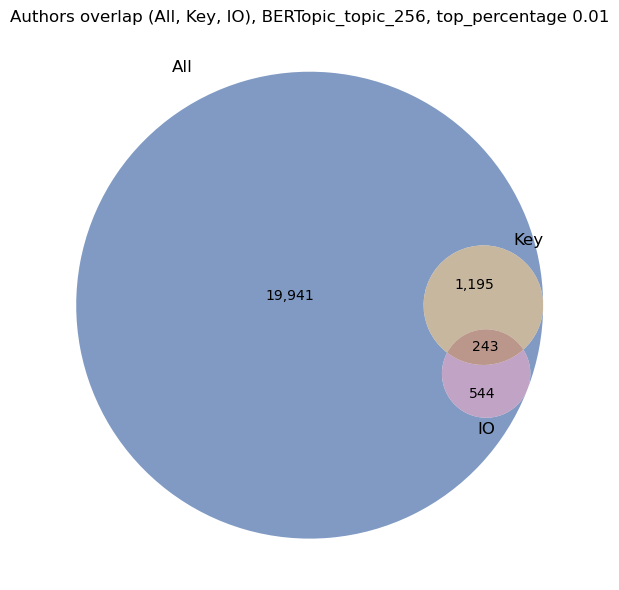

2026-04-30 11:31:31 | Completed: plot_venn_3_sets


In [37]:
# ven for ("All", "Key", "IO"),

if run_demo:

    print(f"Using topic column: {topic_col}")
    plot_venn_3_sets(
        set_a=all_authors_set,
        set_b=all_topics_key_authors_set,
        set_c=io_authors_set,
        title=f"Authors overlap (All, Key, IO), {topic_col}, top_percentage {top_percentage}",
        set_labels=("All", "Key", "IO"),
        folder_output_path=folder_output_path,
    )

Using topic column: BERTopic_topic_256
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/authors_overlap_key_io_boost_top_percentage_001.png


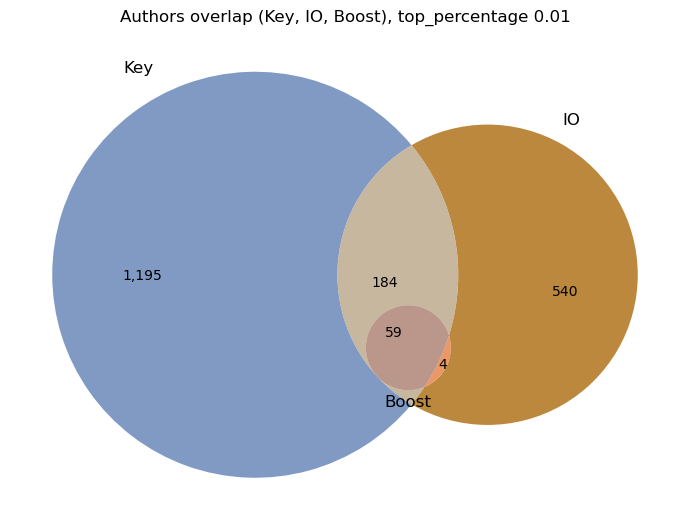

2026-04-30 11:31:31 | Completed: plot_venn_3_sets


In [38]:
# ven for ("Key", "IO", "Boost"),

if run_demo:

    print(f"Using topic column: {topic_col}")
    plot_venn_3_sets(
        set_a=all_topics_key_authors_set,
        set_b=io_authors_set,
        set_c=boost_authors_set,
        title=f"Authors overlap (Key, IO, Boost), top_percentage {top_percentage}",
        set_labels=("Key", "IO", "Boost"),
        folder_output_path=folder_output_path,
    )

# Networkx Graphs

## Parameters

In [39]:
account_relations = [
    # (src_col, dst_col)
    ("in_reply_to_accountid", "accountid"),
    ("account_mentions", "accountid"),
    ("reposted_accountid", "accountid"),

    ("hashtags_reuse_12H_accountids", "accountid"),
    # ("urls_reuse_12H_accountids", "accountid"),
    ("account_mentions_reuse_12H_accountids", "accountid"),
    ("ner_entities_reuse_12H_accountids", "accountid"),
    
    ("hashtags_reuse_3D_accountids", "accountid"),
    # ("urls_reuse_3D_accountids", "accountid"),
    ("account_mentions_reuse_3D_accountids", "accountid"),
    ("ner_entities_reuse_3D_accountids", "accountid")

    # text similarity, not implemented
]

## Build Account ↔ Account Graph

In [40]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_set: set | None = None,  # if given, only add edges where both src and dst are in this set
) -> None:
    """Add weighted edges to a graph from co-occurrence counts of (src, dst) pairs.

    Edge weights are incremented by `weight` for each co-occurrence.

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_set: set of authors to add edges for. If None, adds edges for all authors.

    Returns:
        None
    """

    print(f"[add_relation_edges] Adding {src_col} -> {dst_col} Edges")
    
    # make pairs of src-dst
    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    # filter to key authors
    if all_topics_key_authors_set is not None:
        pairs = pairs[pairs[src_col].isin(all_topics_key_authors_set) & pairs[dst_col].isin(all_topics_key_authors_set)]

    # remove self loops
    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # aggregate counts of (src, dst) pairs → edge weights
    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count") # columns: [src_col, dst_col, count]

    # main loop
    for row in tqdm(counts.itertuples(index=False), desc=f"Adding edges for {src_col} -> {dst_col}"):
        src = getattr(row, src_col)
        dst = getattr(row, dst_col)
        w = int(row.count) * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            continue

        # add the edge (automatically add nodes if needed)
        G.add_edge(src, dst, weight=w)

    return None

In [41]:
def add_nodes_labels(
    df: pd.DataFrame,
    G: nx.Graph,
    author_col: str,
    topic_col: str,
    io_authors: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    boost_score_df: pd.DataFrame | None = None,
) -> None:
    """Attach all node-level labels to graph nodes.

    Labels added:
        * io_author: 1 if author in io_authors, else 0
        * top_topic: topic with the highest key score
        * top_topic_key_score: score of the top topic
        * top_5_topics: comma-separated top 5 topic IDs by score
        * all_topics_key_score_sum: sum of all topic scores
        * key_score_dominance: max score / (sum + eps), higher = more concentrated
        * posting_dominance: max topic post count / total posts
        * boost_score: boost score for the author (0.0 if not in boost_score_df)

    Args:
        df: DataFrame containing posts.
        G: Graph whose nodes are authors.
        author_col: Column with author IDs.
        topic_col: Column with topic labels.
        io_authors: Optional set of IO-labeled authors.
        author_topic_key_score_df: Optional DataFrame with author-topic scores
            (index=author, columns=topics, values=score).
        boost_score_df: Optional DataFrame with columns [accountid, boost_score].

    Returns:
        None. Updates G node attributes in-place.
    """

    print(f"[add_nodes_labels] Adding node labels to graph nodes based on author column: {author_col} and topic column: {topic_col}")

    node_authors = pd.Index(map(str, G.nodes))

    # --- IO author label ---
    if io_authors is not None:
        io_authors_set = set(map(str, io_authors))
        nx.set_node_attributes(
            G,
            {author: int(author in io_authors_set) for author in node_authors},
            "io_author",
        )

    # --- Key-score labels ---
    if author_topic_key_score_df is not None:
        # Set defaults first so every node has the same attributes.
        nx.set_node_attributes(G, {author: -1 for author in node_authors}, "top_topic")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "top_topic_key_score")
        nx.set_node_attributes(G, {author: "" for author in node_authors}, "top_5_topics")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "all_topics_key_score_sum")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "key_score_dominance")

        key_scores = author_topic_key_score_df.copy()
        key_scores.index = key_scores.index.astype(str)

        available_authors = node_authors.intersection(key_scores.index)
        missing_count = len(node_authors) - len(available_authors)
        if missing_count > 0:
            print(
                f"[add_nodes_labels] {missing_count} graph authors were missing from author_topic_key_score_df; using defaults for them."
            )

        if len(available_authors) > 0:
            author_score_matrix = key_scores.loc[available_authors]

            top_topics = author_score_matrix.idxmax(axis=1)
            top_topic_scores = author_score_matrix.max(axis=1)
            score_sums = author_score_matrix.sum(axis=1)
            key_score_dominance = top_topic_scores / (score_sums + 1e-6)

            # Keep top-5 topic labels for explainability in exports.
            top_5_topics = author_score_matrix.apply(
                lambda row: ",".join(map(str, row.nlargest(5).index.tolist())),
                axis=1,
            )

            nx.set_node_attributes(G, top_topics.to_dict(), "top_topic")
            nx.set_node_attributes(G, top_topic_scores.to_dict(), "top_topic_key_score")
            nx.set_node_attributes(G, top_5_topics.to_dict(), "top_5_topics")
            nx.set_node_attributes(G, score_sums.to_dict(), "all_topics_key_score_sum")
            nx.set_node_attributes(G, key_score_dominance.to_dict(), "key_score_dominance")

    # --- Boost score label ---
    if boost_score_df is not None:
        boost_score_map = (
            boost_score_df.assign(**{author_col: boost_score_df[author_col].astype(str)})
            .set_index(author_col)["boost_score"]
            .to_dict()
        )
        nx.set_node_attributes(
            G,
            {author: float(boost_score_map.get(author, 0.0)) for author in node_authors},
            "boost_score",
        )

    # --- Posting dominance ---
    # Count posts per (author, topic) and compute concentration ratio per author.
    author_topic_counts = (
        df[[author_col, topic_col]]
        .dropna()
        .assign(**{author_col: lambda x: x[author_col].astype(str)})
        .groupby([author_col, topic_col])
        .size()
    )

    max_counts = author_topic_counts.groupby(level=0).max()
    total_counts = author_topic_counts.groupby(level=0).sum()
    posting_dominance = (max_counts / (total_counts + 1e-6)).to_dict()

    nx.set_node_attributes(
        G,
        {author: float(posting_dominance.get(author, 0.0)) for author in node_authors},
        "posting_dominance",
    )

In [42]:
@report_done
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    topic_col: str = "BERTopic_topic_512",
    io_authors: set | None = None,
    all_topics_key_authors_set: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    boost_score_df: pd.DataFrame | None = None,
    is_directed_graphs: bool = True,
    output_path: Path | None = None,
    author_col: str = "accountid",
    graph_name: str = "accounts_graph",
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        topic_col: Topic column name.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_set: Optional set of key authors. When provided,
            df is pre-filtered to rows by key authors and non-key-author nodes
            are pruned after edge construction.
        author_topic_key_score_df: Optional DataFrame with author-topic scores for node labels.
        boost_score_df: Optional DataFrame with columns [accountid, boost_score] for node labels.
        is_directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).
        output_path: If provided, writes `<output_path>/<topic_col>_accounts_graph.gexf`.
        author_col: Column name for author IDs.
        graph_name: Name to assign to the graph .

    Returns:
        nx.DiGraph: The constructed accounts graph.
    """

    print(f"[build_accounts_graph] Building accounts graph with topic column: {topic_col}, and account relations: {account_relations}")

    # create graph
    if is_directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = f"{topic_col}_{graph_name}"

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if author_topic_key_score_df is None:
        print("Warning: author_topic_key_score_df is None. No node score-labels will be included.")
    if boost_score_df is None:
        print("Warning: boost_score_df is None. No boost_score labels will be included.")
        

    # Add edges

    if all_topics_key_authors_set is None:
        print(f"[build_accounts_graph] Warning: all_topics_key_authors_set is None, not filtering edges to key authors.")
    
    for src_col, dst_col in tqdm(account_relations, desc=f"Adding account edges"):

        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_set = all_topics_key_authors_set,
        )

    # Add all node labels (io_author, key scores, boost score, posting dominance)
    add_nodes_labels(
        df,
        G,
        author_col=author_col,
        topic_col=topic_col,
        io_authors=io_authors,
        author_topic_key_score_df=author_topic_key_score_df,
        boost_score_df=boost_score_df,
    )


    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{G.graph['name']}.gexf"
        nx.write_gexf(G, graph_output_path)
        print(f"Saved graph to: {graph_output_path}")


    # print graph stats
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    print(f"\n[build_accounts_graph] Graph construction complete. Nodes: {n_nodes:,}, Edges: {n_edges:,}")

    return G

In [43]:
if run_demo:
    G_accounts = build_accounts_graph(
        df=df,
        account_relations = account_relations,
        topic_col=topic_col,
        io_authors=io_authors_set,
        all_topics_key_authors_set = boost_and_key_authors_union_set, # key authors and boost authors combined
        author_topic_key_score_df = author_topic_key_score_df,
        boost_score_df = boost_df,
        is_directed_graphs = True,
        output_path = folder_output_path,
        author_col = account_id_col,
    )

[build_accounts_graph] Building accounts graph with topic column: BERTopic_topic_256, and account relations: [('in_reply_to_accountid', 'accountid'), ('account_mentions', 'accountid'), ('reposted_accountid', 'accountid'), ('hashtags_reuse_12H_accountids', 'accountid'), ('account_mentions_reuse_12H_accountids', 'accountid'), ('ner_entities_reuse_12H_accountids', 'accountid'), ('hashtags_reuse_3D_accountids', 'accountid'), ('account_mentions_reuse_3D_accountids', 'accountid'), ('ner_entities_reuse_3D_accountids', 'accountid')]


Adding account edges:   0%|          | 0/9 [00:00<?, ?it/s]

[add_relation_edges] Adding in_reply_to_accountid -> accountid Edges


Adding edges for in_reply_to_accountid -> accountid: 454it [00:00, 269375.30it/s]

[add_relation_edges] Adding account_mentions -> accountid Edges


...

[add_relation_edges] Adding account_mentions_reuse_3D_accountids -> accountid Edges


Adding edges for account_mentions_reuse_3D_accountids -> accountid: 36018it [00:00, 353477.89it/s]
Adding account edges:  89%|████████▉ | 8/9 [00:22<00:04,  4.56s/it]

[add_relation_edges] Adding ner_entities_reuse_3D_accountids -> accountid Edges


Adding edges for ner_entities_reuse_3D_accountids -> accountid: 44268it [00:00, 362705.80it/s]
Adding account edges: 100%|██████████| 9/9 [00:24<00:00,  2.75s/it]


[add_nodes_labels] Adding node labels to graph nodes based on author column: accountid and topic column: BERTopic_topic_256
Saved graph to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/BERTopic_topic_256_accounts_graph.gexf

[build_accounts_graph] Graph construction complete. Nodes: 1,403, Edges: 56,280
2026-04-30 11:31:57 | Completed: build_accounts_graph


## Plot Accounts Graph

In [44]:
def _get_pos(graph: nx.Graph, layout_name: str):
    if layout_name == "spring":
        return nx.spring_layout(graph, iterations=300)
    elif layout_name == "circular":
        return nx.circular_layout(graph)
    elif layout_name == "random":
        return nx.random_layout(build_accounts_graph)
    elif layout_name == "shell":
        return nx.shell_layout(graph)
    elif layout_name == "spectral":
        return nx.spectral_layout(graph)
    elif layout_name == "kamada_kawai":
        return nx.kamada_kawai_layout(graph)
    else:
        raise ValueError(f"Unknown layout: {layout_name}")

In [ ]:
@report_done
def plot_accounts_graph(
    G: nx.Graph | list[nx.Graph],
    folder_output_path: str | Path | None = None,
    graph_name: str | None = None,
    figsize: tuple = (14, 14),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
    title: str | list[str] | None = None,
):
    """Plot one NetworkX graph or multiple graphs as subplots.

    Args:
        G: A single graph or a list of graphs.
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: File name for the saved figure.
        figsize: Figure size.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX.
        title: Optional title for a single graph, or list of titles for multiple graphs.
    """
    import math

    def filter_graph(graph: nx.Graph, authors: set | Iterable | None) -> nx.Graph:
        if authors is not None:
            authors = set(map(str, authors))
            return graph.subgraph(authors)
        return graph

    def _draw_one(ax, graph: nx.Graph, subplot_title: str | None = None):

        G_plot = filter_graph(graph, key_authors)

        n_nodes = G_plot.number_of_nodes()
        n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
        n_legitimate = n_nodes - n_io
        io_pct = 100 * n_io / n_nodes if n_nodes > 0 else 0

        print(
            f"[plot_accounts_graph] Plotting graph with {n_nodes:,} nodes: "
            f"{n_legitimate:,} legitimate authors, {n_io:,} IO authors, "
            f"IO percentage: {io_pct:.1f}%"
        )
        print(f"[plot_accounts_graph] Layout: {layout}")

        pos = _get_pos(G_plot, layout)

        node_colors = [
            "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
            for n in G_plot.nodes
        ]

        nx.draw(
            G_plot,
            pos,
            ax=ax,
            node_size=30,
            node_color=node_colors,
            edge_color="gray",
            width=0.5,
            alpha=0.8,
            with_labels=False,
        )

        legend_elements = [
            mpatches.Patch(
                color="steelblue",
                label=f"Non-IO author ({n_legitimate:,} nodes, {(100 - io_pct):.1f}%)",
            ),
            mpatches.Patch(
                color="red",
                label=f"IO author ({n_io:,} nodes, {io_pct:.1f}%)",
            ),
        ]
        ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=12)

        if subplot_title is not None:
            ax.set_title(subplot_title, fontsize=18)

        ax.text(
            0.5,
            -0.06,
            f"Layout: {layout}",
            transform=ax.transAxes,
            ha="center",
            fontsize=12,
        )
        ax.set_axis_off()

    graphs = G if isinstance(G, list) else [G]
    n_graphs = len(graphs)

    if isinstance(title, list):
        if len(title) != n_graphs:
            raise ValueError(f"title must have length {n_graphs}, got {len(title)}")
        titles = title
    else:
        titles = [title] * n_graphs

    if n_graphs == 1:
        fig, ax = plt.subplots(figsize=figsize)
        _draw_one(ax, graphs[0], titles[0])
    else:
        ncols = min(3, n_graphs)
        nrows = math.ceil(n_graphs / ncols)

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axes = np.array(axes).reshape(-1)

        for ax, graph, subplot_title in zip(axes, graphs, titles):
            _draw_one(ax, graph, subplot_title)

        for ax in axes[n_graphs:]:
            ax.set_visible(False)

    plt.tight_layout()

    if folder_output_path is not None:
        if graph_name is None:
            if n_graphs == 1:
                graph_name = graphs[0].graph.get("name", "accounts_graph")
            else:
                graph_name = "accounts_graphs"

        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()

In [46]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'

# if run_demo:
#     plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, layout="spring")

# TODO: uncomment if needed

# IO Indicators

e.g, centralities, core number

## Compute Indicators


[Facebook Network Analysis](https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html) </br>
[NX Algoritms](https://networkx.org/documentation/stable/reference/algorithms/index.html)

In [47]:
# import time

# @report_done
# def compute_indicators(G: nx.Graph, output_folder_path: str | Path | None = None, k: int = 500) -> pd.DataFrame:
#     """Compute multiple graph indicators.
#     The indicators are for the nodes (authors) in the graph, and include various centrality measures, clustering coefficients, and key-author scores.
#     https://networkx.org/documentation/stable/reference/algorithms/index.html

#     Args:
#         G: NetworkX graph
#         output_folder_path: Path to the folder where the output will be saved
#         k: Maximum number of nodes for betweenness centrality calculation.

#     Returns:
#         indicators_df: DataFrame indexed by author/node with the computed indicators.

    

#     Returns a DataFrame indexed by author/node with:
#       - degree centrality (centrality)
#       - betweenness centrality (centrality)
#       - closeness centrality (centrality)
#       - harmonic centrality (centrality)
#       - load centrality (centrality)
#       - eigenvector centrality (centrality)
#       - node_clique_number (clique)
#       - pagerank (link analysis)
#       - kcore (core)
#       - clustering coefficient (clustering)
#       - triangles (clustering)
#       - square_clustering (clustering)
#       - sum tfidf score across all topics (key-authors score) # not NX
#       - coefficient of variation of key scores across topics (key-authors score) # not NX

#     """
    
#     timing_report = {}
    
#     # ------------------------------------------
#     #            Graph Indicators 
#     # ------------------------------------------

#     n_nodes = G.number_of_nodes()

#     # Degree centrality
#     print("Calculating: degree_centrality")
#     start_time = time.time()
#     degree = nx.degree_centrality(G)
#     timing_report["degree_centrality"] = time.time() - start_time
    

#     # # Betweenness centrality
#     print("Calculating: betweenness_centrality")
#     start_time = time.time()
#     if n_nodes > k:
#         print(f"Graph has {n_nodes:,} nodes, which may make betweenness centrality calculation slow. Using {k:,} nodes sample for approximation.")
#         betweenness = nx.betweenness_centrality(G, normalized=True, k=k)
#     else:
#         betweenness = nx.betweenness_centrality(G, normalized=True)
#     timing_report["betweenness_centrality"] = time.time() - start_time

#     # Closeness centrality
#     # print("Calculating: closeness_centrality")
#     # closeness = nx.closeness_centrality(G)

#     # Harmonic centrality
#     print("Calculating: harmonic_centrality")
#     start_time = time.time()
#     harmonic = nx.harmonic_centrality(G)
#     timing_report["harmonic_centrality"] = time.time() - start_time

#     # Load centrality
#     # print("Calculating: load_centrality")
#     # load = nx.load_centrality(G, normalized=True)

#     # Eigenvector centrality
#     print("Calculating: eigenvector_centrality")
#     start_time = time.time()
#     eigen = nx.eigenvector_centrality(G, max_iter=2000)
#     timing_report["eigenvector_centrality"] = time.time() - start_time

#     # node_clique_number # high correlation with k-core
#     # print("Calculating: node_clique_number")
#     # node_clique_number = nx.node_clique_number(G.to_undirected())
    
#     # PageRank
#     print("Calculating: pagerank")
#     start_time = time.time()
#     pagerank = nx.pagerank(G)
#     timing_report["pagerank"] = time.time() - start_time

#      # K-core number
#     print("Calculating: core_number")
#     start_time = time.time()
#     kcore = nx.core_number(G)
#     timing_report["core_number"] = time.time() - start_time

#     # Clustering
#     print("Calculating: clustering")
#     start_time = time.time()
#     clustering = nx.clustering(G)
#     timing_report["clustering"] = time.time() - start_time

#     # triangles # high correlation with k-core
#     # print("Calculating: triangles")
#     # triangles = nx.triangles(G.to_undirected())

#     # Square clustering
#     print("Calculating: square_clustering")
#     start_time = time.time()
#     square_clustering = nx.square_clustering(G)
#     timing_report["square_clustering"] = time.time() - start_time

#   # Community detection (greedy modularity)
#   print("Calculating: Communities (greedy modularity)")

    # communities = nx.community.greedy_modularity_communities(G, weight="weight")

    # node_to_community = {}
    # for community_id, nodes in enumerate(communities):
    #     for node in nodes:
    #         node_to_community[node] = community_id



#     # ------------------------------------------
#     #           Key Score Indicators 
#     # ------------------------------------------

#     # Sum of key scores across all topics (set by add_relation_edges)
#     print("Fetching: all_topics_key_score_sum")
#     start_time = time.time()
#     all_topics_key_score_sum: dict[str, float] = {
#         node: G.nodes[node]["all_topics_key_score_sum"]
#         for node in G.nodes
#     }
#     timing_report["all_topics_key_score_sum"] = time.time() - start_time

#     # Coefficient of variation of key scores across topics (set by add_relation_edges)
#     # High dominance = author is concentrated in few topics.
#     print("Fetching: key_score_dominance")
#     start_time = time.time()
#     key_score_dominance: dict[str, float] = {
#         node: G.nodes[node]["key_score_dominance"]
#         for node in G.nodes
#     }
#     timing_report["key_score_dominance"] = time.time() - start_time

#     print("Fetching: posting_dominance")
#     start_time = time.time()
#     posting_dominance: dict[str, float] = {
#         node: G.nodes[node]["posting_dominance"]
#         for node in G.nodes
#     }
#     timing_report["posting_dominance"] = time.time() - start_time

#     print("Fetching: Boost Score")
#     start_time = time.time()
#     boost_score: dict[str, float] = {
#         node: G.nodes[node]["boost_score"]
#         for node in G.nodes
#     }
#     timing_report["boost_score"] = time.time() - start_time

#     # Build DataFrame
#     node_indicators_df = pd.DataFrame(
#         {
#             "degree_centrality": degree,
#             # "betweenness_centrality": betweenness,
#             # "closeness_centrality": closeness, # high correlation with closeness
#             "harmonic_centrality": harmonic, 
#             "eigenvector_centrality": eigen,
#             # "load_centrality": load, # high correlation with betweenness
#             # "node_clique_number": node_clique_number, # high correlation with k-core
#             "pagerank": pagerank,
#             "kcore": kcore,
#             "clustering": clustering,
#             # "triangles": triangles, # high correlation with k-core
#             "square_clustering": square_clustering,
#             "key_score_sum": all_topics_key_score_sum,
#             "key_score_dominance": key_score_dominance, # max-score / sum-of-scores. Higher means more concentrated.
#             "posting_dominance": posting_dominance,
#             "boost_score": boost_score,
#             "community": node_to_community,
#         }
#     )

#     node_indicators_df.index.name = "accountid"

#     # Print timing report
#     print("\n" + "="*50)
#     print("INDICATOR CALCULATION TIME REPORT")
#     print("="*50)
#     for indicator, elapsed_time in sorted(timing_report.items(), key=lambda x: x[1], reverse=True):
#         print(f"{indicator:.<35} {elapsed_time:>8.2f}s")
#     total_time = sum(timing_report.values())
#     print("-"*50)
#     print(f"{'TOTAL':.<35} {total_time:>8.2f}s")
#     print("="*50 + "\n")

#     if output_folder_path is not None:
#         node_indicators_df_path = Path(output_folder_path) / "node_indicators.parquet"
#         node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")
#         print(f"node_indicators_df is saved to: {node_indicators_df_path}")


#     return node_indicators_df

In [48]:
import os
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import networkx as nx
import pandas as pd

In [49]:
_GRAPH = None


def _init_indicator_worker(graph: nx.Graph) -> None:
    """Store graph once per worker process."""
    global _GRAPH
    _GRAPH = graph


def _compute_indicator(indicator_name: str) -> tuple[str, dict, float]:
    """Compute one indicator by name.

    Args:
        indicator_name: Indicator name.

    Returns:
        Tuple of:
            indicator_name,
            dict {node: indicator_value},
            execution time in seconds.
    """
    global _GRAPH

    print(f"[_compute_indicator] (PID {os.getpid()}) Starting computing {indicator_name}\n")
    start_time = time.time()

    G = _GRAPH

    indicator_funcs = {
        "degree_centrality": lambda: nx.degree_centrality(G),
        "harmonic_centrality": lambda: nx.harmonic_centrality(G, distance="weight"),
        "betweenness_centrality": lambda: nx.betweenness_centrality(G, weight="weight", normalized=True),
        "eigenvector_centrality": lambda: nx.eigenvector_centrality(G, weight="weight"),
        "pagerank": lambda: nx.pagerank(G, weight="weight"),
        "kcore": lambda: nx.core_number(G),
        "clustering": lambda: nx.clustering(G, weight="weight"),
        "square_clustering": lambda: nx.square_clustering(G),
        "key_score_sum": lambda: {
            node: G.nodes[node].get("all_topics_key_score_sum", 0.0)
            for node in G.nodes
        },
        "key_score_dominance": lambda: {
            node: G.nodes[node].get("key_score_dominance", 0.0)
            for node in G.nodes
        },
        "posting_dominance": lambda: {
            node: G.nodes[node].get("posting_dominance", 0.0)
            for node in G.nodes
        },
        "boost_score": lambda: {
            node: G.nodes[node].get("boost_score", 0.0)
            for node in G.nodes
        },
        "top_topic": lambda: {
            node: G.nodes[node].get("top_topic", -1)
            for node in G.nodes
        },
        "louvain_community": lambda: _compute_louvain_community_map(G),
    }

    if indicator_name not in indicator_funcs:
        raise ValueError(f"Unknown indicator: {indicator_name}")

    nodes_to_indicator_dict = indicator_funcs[indicator_name]()
    execution_time = time.time() - start_time


    print(f"[_compute_indicator] (PID {os.getpid()}) Finished computing {indicator_name} in {execution_time:.2f}s\n")

    return indicator_name, nodes_to_indicator_dict, execution_time


def _compute_louvain_community_map(G: nx.Graph) -> dict:
    """Run Louvain community detection and return node -> community id."""
    communities = nx.community.louvain_communities(G, weight="weight")

    node_to_community = {}
    for community_id, nodes in enumerate(communities):
        for node in nodes:
            node_to_community[node] = community_id

    return node_to_community

In [ ]:
@report_done
def compute_indicators(
    G: nx.Graph,
    output_folder_path: str | Path | None = None,
    max_workers: int | None = 4,
) -> pd.DataFrame:
    """Compute graph indicators in parallel with ProcessPoolExecutor.map.

    Args:
        G: NetworkX graph.
        output_folder_path: Optional folder to save parquet output.
        max_workers: Number of worker processes.

    Returns:
        DataFrame indexed by node/accountid with computed indicators.
    """
    indicator_names = [
        "degree_centrality",
        "harmonic_centrality",
        "eigenvector_centrality",
        "betweenness_centrality",
        "pagerank",
        "kcore",
        "clustering",
        "square_clustering",
        "key_score_sum",
        "key_score_dominance",
        "posting_dominance",
        "boost_score",
        "top_topic",
        "louvain_community",
    ]

    print(
        f"[compute_indicators] Computing indicators in parallel\n"
        f"Graph name: {G.graph.get('name', 'Unknown')}\n"
        f"Graph number of nodes: {G.number_of_nodes():,}, "
        f"number of edges: {G.number_of_edges():,}"
    )

    results = {}
    execution_times = {}

    with ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_indicator_worker,
        initargs=(G,),
    ) as executor:
        for indicator_name, nodes_to_indicator_dict, execution_time in tqdm(
            executor.map(
                _compute_indicator,
                indicator_names,
            ),
            total=len(indicator_names),
            desc="Computing indicators",
        ):
            results[indicator_name] = nodes_to_indicator_dict
            execution_times[indicator_name] = execution_time


    node_indicators_df = pd.DataFrame(results)
    node_indicators_df.index.name = "accountid"

    print("\n" + "=" * 50)
    print("INDICATOR CALCULATION TIME REPORT")
    print("=" * 50)
    for indicator, elapsed_time in sorted(
        execution_times.items(),
        key=lambda x: x[1],
        reverse=True,
    ):
        print(f"{indicator:.<35} {elapsed_time:>8.2f}s")
    print("-" * 50)
    print(f"{'TOTAL':.<35} {sum(execution_times.values()):>8.2f}s")
    print("=" * 50 + "\n")


    if output_folder_path is not None:
        
        output_folder_path = Path(output_folder_path)
        graph_name = G.graph.get("name", "accounts_graph")
        node_indicators_df_path = output_folder_path / f"{graph_name}_node_indicators.parquet"
        
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")

        print(f"node_indicators_df is saved to: {node_indicators_df_path}")

    return node_indicators_df

In [51]:
if run_demo:
    node_indicators_df = compute_indicators(G_accounts, output_folder_path = folder_output_path)
    node_indicators_df.head()

[compute_indicators] Computing indicators in parallel
Graph name: BERTopic_topic_256_accounts_graph
Graph number of nodes: 1,403, number of edges: 56,280
[_compute_indicator] (PID 2701712) Starting computing eigenvector_centrality
[_compute_indicator] (PID 2701710) Starting computing degree_centrality

[_compute_indicator] (PID 2701711) Starting computing harmonic_centrality
[_compute_indicator] (PID 2701713) Starting computing betweenness_centrality


[_compute_indicator] (PID 2701710) Finished computing degree_centrality in 0.00s


[_compute_indicator] (PID 2701710) Starting computing pagerank

[_compute_indicator] (PID 2701710) Finished computing pagerank in 0.10s

[_compute_indicator] (PID 2701710) Starting computing kcore

[_compute_indicator] (PID 2701712) Finished computing eigenvector_centrality in 0.33s

[_compute_indicator] (PID 2701712) Starting computing clustering

[_compute_indicator] (PID 2701710) Finished computing kcore in 0.22s

[_compute_indicator] (PID 2701710) Star

## Add Missing Authors with Zeros

In [52]:
def add_missing_authors_with_zeros(
    node_indicators_df: pd.DataFrame,
    all_authors: Iterable[str],
) -> pd.DataFrame:
    """Ensure all authors exist in the indicators DataFrame.

    If `all_authors` is provided, this function adds any missing authors
    (i.e., authors not present in the DataFrame index) with indicator values set to zero.

    Args:
        node_indicators_df (pd.DataFrame):
            DataFrame where index represents author IDs and columns are numeric indicators.
        all_authors (Iterable[str]):
            Iterable of all expected author IDs.

    Returns:
        pd.DataFrame:
            Updated DataFrame containing all authors, with missing ones added and filled with zeros.

    Notes:
        - Author IDs are converted to strings for consistency.
        - Preserves the original index name.
    """

    all_authors_set = set(map(str, all_authors))
    existing_authors = set(node_indicators_df.index.astype(str))
    missing_authors = all_authors_set - existing_authors

    if not missing_authors:
        return node_indicators_df

    # Create zero-filled rows for missing authors
    zero_df = pd.DataFrame(
        0.0,
        index=list(missing_authors),
        columns=node_indicators_df.columns,
    )
    zero_df.index.name = node_indicators_df.index.name

    node_indicators_df = pd.concat([node_indicators_df, zero_df], axis=0)

    print(f"[add_missing_authors_with_zeros] Added {len(missing_authors)} missing authors with indicators values set to zero.")

    return node_indicators_df

## Indicators Correlation

Saved indicators correlation heatmap to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_correlation_heatmap.png


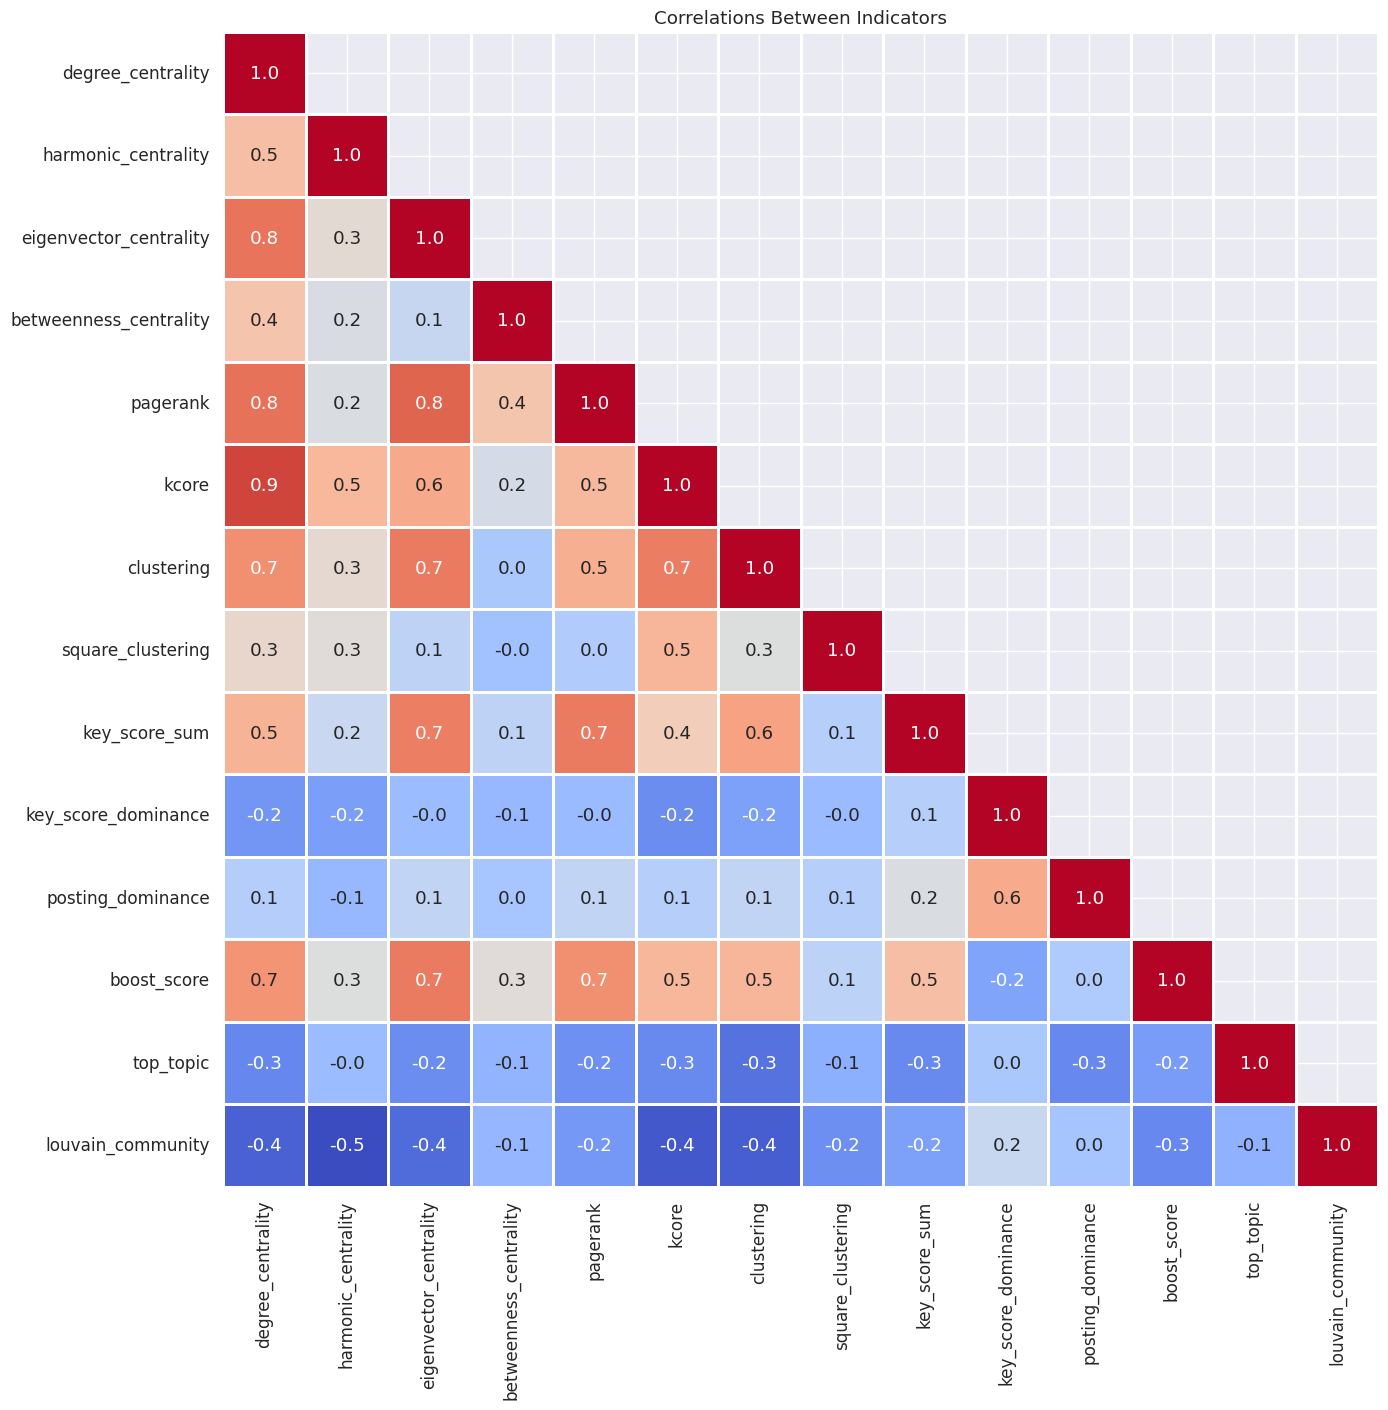

In [53]:
# Display correlations between indicators.
if run_demo:
    corr = node_indicators_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.set(font_scale=1.1)
    plt.figure(figsize=(15, 15))
    sns.heatmap(corr,
                annot=True,
                fmt='.1f',
                cmap='coolwarm',
                square=True,
                mask = mask,
                linewidths=1,
                cbar=False)
    plt.title("Correlations Between Indicators")


    plt.savefig(folder_output_path / "indicators_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    print(f"Saved indicators correlation heatmap to: {folder_output_path / 'indicators_correlation_heatmap.png'}")

    plt.show()
    plt.close()

## Z-Score

In [54]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [55]:
@report_done
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [56]:
if run_demo:
    node_indicators_zscore_df = compute_zscore(node_indicators_df)
    print("#### zscore ####")
    node_indicators_zscore_df.head()

2026-04-30 11:32:43 | Completed: compute_zscore
#### zscore ####


## Account Indicators Summery

In [57]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [58]:
if run_demo:
    suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


    show_account_indicators(
        accountid = suspect_accountid,
        node_indicators_df = node_indicators_df,
        node_indicators_zscore_df = node_indicators_zscore_df,
    )

Account ID: f7b0cd43f0a4521cd6421ba0763b5c977b70cf2832


,indicator,value,z_score
0,degree_centrality,0.025,-0.37
1,harmonic_centrality,300.881,0.92
2,eigenvector_centrality,0.000,-0.23
3,betweenness_centrality,0.011,0.80
4,pagerank,0.000,-0.53
5,kcore,31.000,-0.36
6,clustering,0.000,-0.41
7,square_clustering,0.156,-0.46
8,key_score_sum,14.293,-0.47
9,key_score_dominance,0.827,0.25


## Information Gain

In [59]:
@report_done
def compute_indicators_information_gain(
    node_indicators_df: pd.DataFrame,
    io_authors: set,
    folder_path: str | Path | None = None,
    all_authors: Iterable[str] | None = None,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_indicators_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).
        folder_path: Optional path to save the information gain results.
        all_authors: Optional iterable of all author IDs. If provided, missing authors
            are added to node_indicators_df with zero-valued indicators, ensuring
            information gain is computed over the complete author population.

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    
    # If all_authors provided, add missing authors with zero indicators
    if all_authors is not None:
        node_indicators_df = add_missing_authors_with_zeros(node_indicators_df, all_authors)

    authors = node_indicators_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_indicators_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_indicators_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    # Save results
    if folder_path is not None:
        folder_path = Path(folder_path)
        info_gain_output_path = folder_path / "indicators_information_gain.parquet"
        mi_series.to_frame().to_parquet(info_gain_output_path, compression = "gzip")
        print(f"Saved information gain results to: {info_gain_output_path}")

    return mi_series

In [60]:
if run_demo:
    mi_series = compute_indicators_information_gain(
        node_indicators_df,
        io_authors_set,
        folder_output_path,
        all_authors=df[account_id_col].astype(str).unique(),
    )
    display(mi_series)

[add_missing_authors_with_zeros] Added 20520 missing authors with indicators values set to zero.
Saved information gain results to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_information_gain.parquet
2026-04-30 11:32:44 | Completed: compute_indicators_information_gain


kcore                     0.037390
degree_centrality         0.036171
eigenvector_centrality    0.031579
clustering                0.028464
boost_score               0.026593
harmonic_centrality       0.022900
square_clustering         0.022504
key_score_dominance       0.021391
posting_dominance         0.020728
pagerank                  0.019757
key_score_sum             0.018539
top_topic                 0.015849
betweenness_centrality    0.012405
louvain_community         0.007787
Name: information_gain, dtype: float64

## Plot

### Indicators Information Gain

In [61]:
@report_done
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "indicators_information_gain.png",
    title: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
        title: Title of the plot.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain")
    plt.xlabel("Indicators")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_information_gain_BERTopic_topic_256.png


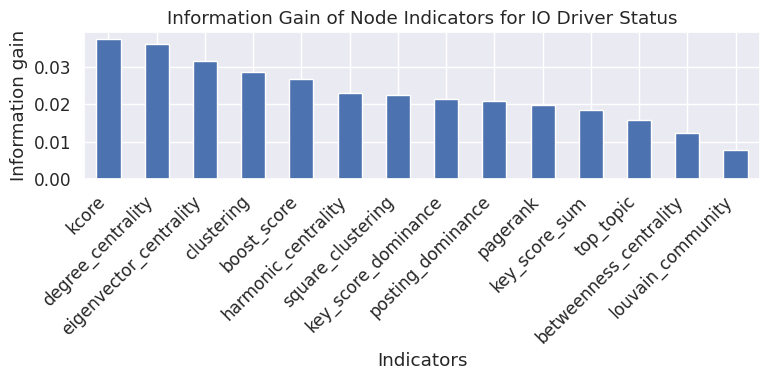

2026-04-30 11:32:44 | Completed: plot_indicators_information_gain


In [62]:
if run_demo:
    plot_indicators_information_gain(mi_series, folder_output_path, filename=f"indicators_information_gain_{topic_col}.png")

In [63]:
# the ig of z-score is the same as the original indicators, since z-scoring is a derivative of the original indicators
# if run_demo:
#     z_score_mi_series = compute_indicators_information_gain(
#         node_indicators_zscore_df,
#         io_authors_set,
#         all_authors=df[account_id_col].astype(str).unique(),
#     )
#     plot_indicators_information_gain(z_score_mi_series, folder_output_path, filename=f"indicators_z_score_information_gain_{topic_col}.png", title = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

### Distributions

In [64]:
@report_done
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of indicators for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved indicators distributions to: {distributions_output_path}")

    plt.show()
    plt.close(fig)

Saved indicators distributions to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_distributions.png


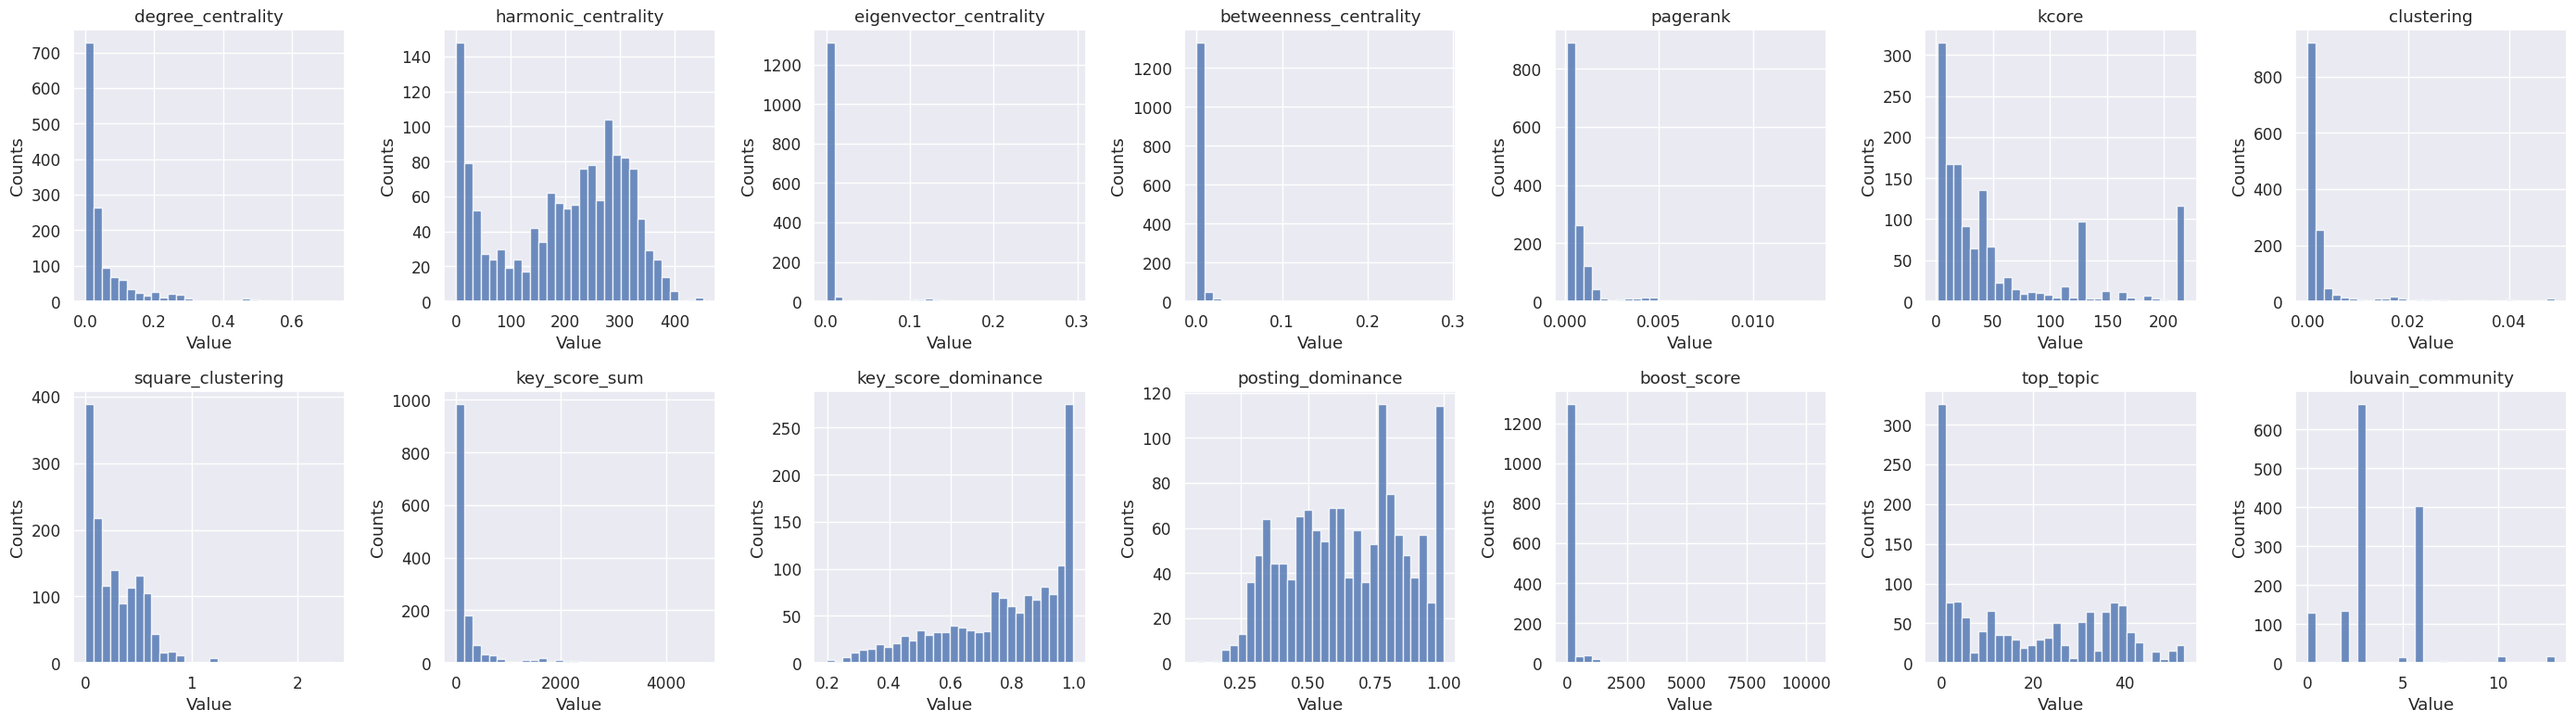

2026-04-30 11:32:47 | Completed: plot_indicators_distributions


In [65]:
if run_demo:
    plot_indicators_distributions(node_indicators_df, folder_output_path)

### Boxplots

In [66]:
@report_done
def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set, output_folder_path: str | Path= None) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
        output_folder_path: Optional path to save the plot image.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 3 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        distributions_output_path = output_folder_path / "indicators_boxplots.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {distributions_output_path}")
    
    plt.show()
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_boxplots.png


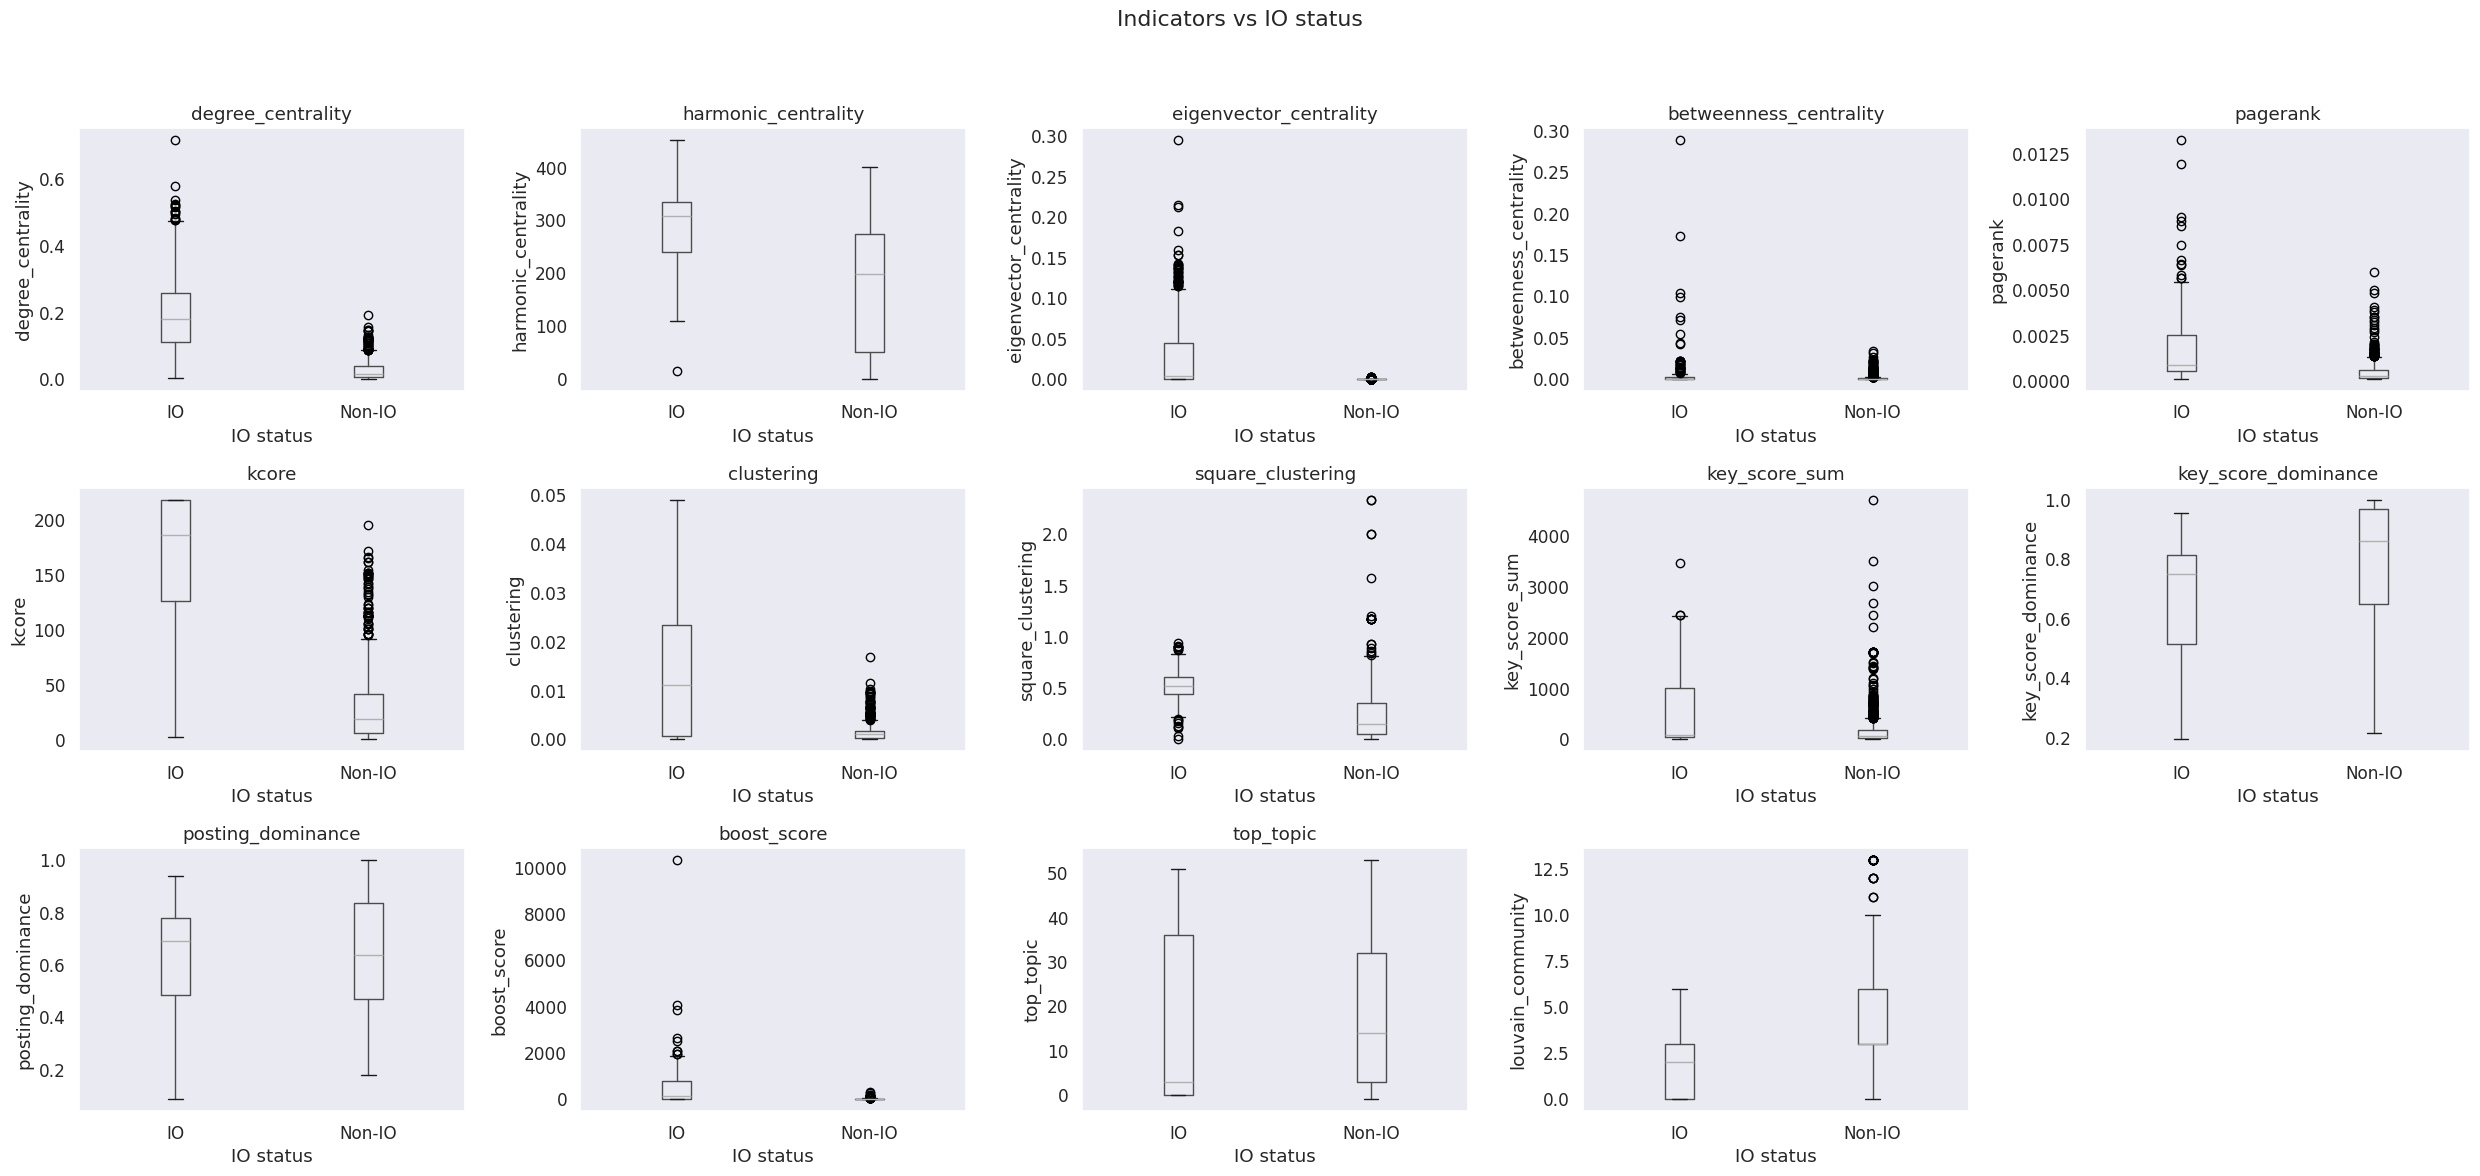

2026-04-30 11:32:49 | Completed: plot_indicator_boxplots


In [67]:
if run_demo:
    plot_indicator_boxplots(node_indicators_df, io_authors_set, output_folder_path = folder_output_path)

## Linear Coefficients

In [68]:
import pandas as pd
from pandas.api.types import is_numeric_dtype

if run_demo:
    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)

    # make it a Series with the same index
    io_binary = pd.Series(io_mask.astype(int), index=node_indicators_df.index, name="io_binary")

    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    coefficients = {}
    for indicator in indicators:
        coefficients[indicator] = node_indicators_df[indicator].corr(io_binary)  # Pearson by default

    coefficients_df = (
        pd.Series(coefficients, name="correlation")
        .sort_values(ascending=False)
        .to_frame()
    )

    # display(coefficients_df)

In [69]:
import matplotlib.pyplot as plt

@report_done
def plot_io_correlations(
        coefficients_df,
        title="Indicator Linear Coefficients with IO Label",
        folder_output_path: str | Path | None = None,
    ) -> None:
    """Plot correlation of graph indicators with IO binary label.

    Args:
        coefficients_df: DataFrame with index=indicator, column 'correlation'.
        title: Plot title.
    """
    df = coefficients_df.sort_values("correlation")

    plt.figure(figsize=(8, max(4, 0.35 * len(df))))
    plt.barh(df.index, df["correlation"])
    plt.axvline(0)
    plt.xlabel("Correlation with IO (binary)")
    plt.title(title)
    plt.tight_layout()
    
    if folder_output_path is not None:
        io_plot_path = Path(folder_output_path) / "indicators_io_linear_coefficients.png"
        plt.savefig(io_plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {io_plot_path}")

    plt.show()
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/indicators_io_linear_coefficients.png


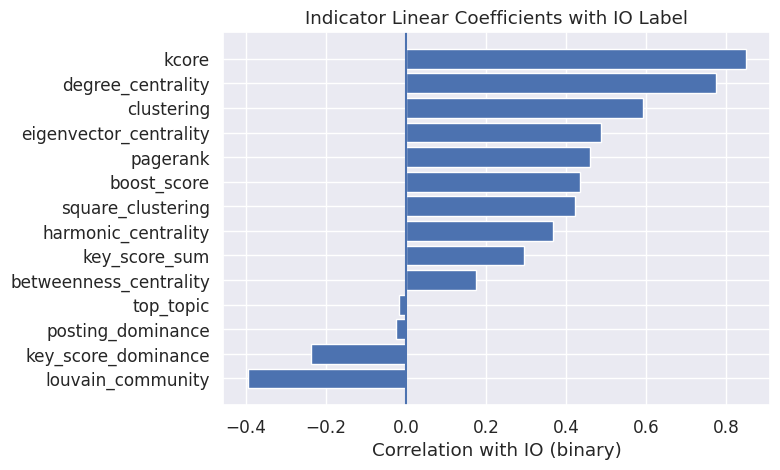

2026-04-30 11:32:49 | Completed: plot_io_correlations


In [70]:
if run_demo:
    plot_io_correlations(coefficients_df, folder_output_path = folder_output_path)

# Classification

In [71]:
# for debugging
print(f"df shape: {df.shape}")

df shape: (1468565, 39)


In [72]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import joblib

In [73]:
def get_classifier(model_name: str, random_state: int = 42, **kwargs):
    """Return a classifier instance by model name.

    Args:
        model_name: Model name. Supported:
            "random_forest", "rf",
            "xgboost", "xgb",
            "logistic_regression", "lr", "logistic"
        random_state: Random seed.
        **kwargs: Extra parameters passed to the model.

    Returns:
        A sklearn-compatible classifier.

    Raises:
        ValueError: If model_name is not supported.
    """
    model_name = model_name.lower()

    if model_name in ["random_forest", "rf"]:
        return RandomForestClassifier(
            random_state=random_state,
            **kwargs,
        )

    if model_name in ["xgboost", "xgb"]:
        return XGBClassifier(
            random_state=random_state,
            eval_metric="logloss",
            **kwargs,
        )

    if model_name in ["logistic_regression", "lr", "logistic"]:
        return LogisticRegression(
            random_state=random_state,
            solver="liblinear",  # safe default
            max_iter=1000,
            **kwargs,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}. "
        "Supported: random_forest/rf, xgboost/xgb, logistic_regression/lr/logistic"
    )

In [74]:
@report_done
def io_classification(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    model_name: str,
    folder_output_path: str | Path | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
):
    """Train and evaluate an IO classifier using the selected model.

    Args:
        node_indicators_df: DataFrame indexed by author IDs, with numeric features.
        io_authors_set: Set of author IDs labeled as IO.
        model_name: Model name. Supported: random_forest/rf, xgboost/xgb, logistic_regression/lr/logistic.
        folder_output_path: Optional folder path to save report and model.
        test_size: Fraction of data used for test split.
        random_state: Random seed.

    Returns:
        tuple(clf, report, auc):
            - clf: Trained classifier
            - report: Classification report string
            - auc: ROC AUC score
    """
    X = node_indicators_df.to_numpy()

    io_authors_set = set(map(str, io_authors_set))
    y = node_indicators_df.index.astype(str).isin(io_authors_set).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    print(f"Training set: {len(X_train)} samples, Test set: {len(X_test)} samples")

    clf = get_classifier(model_name=model_name, random_state=random_state)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, target_names=["Non-IO", "IO"])
    auc = roc_auc_score(y_test, y_proba)

    if folder_output_path is not None:
        folder_output_path = Path(folder_output_path)

        report_path = folder_output_path / f"io_classification_{model_name}_report.txt"
        model_path = folder_output_path / f"io_classification_{model_name}_model.joblib"

        # report
        report_text = (
            f"Model: {model_name}\n"
            f"Training set: {len(X_train):,} samples\n"
            f"Test set: {len(X_test):,} samples\n\n"
            f"{report}\n"
            f"AUC: {auc:.4f}\n"
        )
        print(report_text)
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        # save model
        joblib.dump(clf, model_path)

        write_report(f"Saved report to: {report_path}")
        write_report(f"Saved model to: {model_path}")

    return clf, report, auc

In [75]:
if run_demo:
    rf_model, rf_report, rf_auc = io_classification(node_indicators_df, io_authors_set, "random_forest", folder_output_path)

Training set: 1122 samples, Test set: 281 samples
Model: random_forest
Training set: 1,122 samples
Test set: 281 samples

              precision    recall  f1-score   support

      Non-IO       0.98      1.00      0.99       232
          IO       1.00      0.92      0.96        49

    accuracy                           0.99       281
   macro avg       0.99      0.96      0.97       281
weighted avg       0.99      0.99      0.99       281

AUC: 0.9868

2026-04-30 11:32:50 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_random_forest_report.txt
2026-04-30 11:32:50 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_random_forest_model.joblib
2026-04-30 11:32:50 | Completed: io_classification


In [76]:
if run_demo:
    xgb_model, xgb_report, xgb_auc = io_classification(node_indicators_df, io_authors_set, "xgboost", folder_output_path)

Training set: 1122 samples, Test set: 281 samples
Model: xgboost
Training set: 1,122 samples
Test set: 281 samples

              precision    recall  f1-score   support

      Non-IO       0.99      1.00      0.99       232
          IO       1.00      0.94      0.97        49

    accuracy                           0.99       281
   macro avg       0.99      0.97      0.98       281
weighted avg       0.99      0.99      0.99       281

AUC: 0.9943

2026-04-30 11:32:50 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_xgboost_report.txt
2026-04-30 11:32:50 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_xgboost_model.joblib
2026-04-30 11:32:50 | Completed: io_classification


In [77]:
if run_demo:
    lr_model, lr_report, lr_auc = io_classification(node_indicators_df, io_authors_set, "logistic_regression", folder_output_path)

Training set: 1122 samples, Test set: 281 samples
Model: logistic_regression
Training set: 1,122 samples
Test set: 281 samples

              precision    recall  f1-score   support

      Non-IO       0.99      0.98      0.98       232
          IO       0.92      0.94      0.93        49

    accuracy                           0.98       281
   macro avg       0.95      0.96      0.96       281
weighted avg       0.98      0.98      0.98       281

AUC: 0.9876

2026-04-30 11:32:50 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_logistic_regression_report.txt
2026-04-30 11:32:50 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_classification_logistic_regression_model.joblib
2026-04-30 11:32:50 | Completed: io_classification


## Features Importance

### SHAP

In [78]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

@report_done
def plot_shap_analysis(
    trained_model,
    X: pd.DataFrame,
    folder_output_path: str | Path | None = None,
) -> None:

    """
    Plot SHAP analysis for a tree-based model.

    Args:
        trained_model: Fitted tree-based model.
        X: Data as DataFrame (must include column names).
        folder_output_path: Optional folder path to save the SHAP plots.

    Returns:
        None. Displays SHAP plots.
    """

    explainer = shap.Explainer(trained_model)
    shap_values = explainer(X)

    if folder_output_path is not None:
        folder_output_path = Path(folder_output_path)


    # --- BAR PLOT ---
    shap.plots.bar(shap_values, show=False)

    if folder_output_path is not None:
        shap_bar_path = folder_output_path / "shap_global_importance.png"
        plt.savefig(shap_bar_path, dpi=300, bbox_inches="tight")
        print(f"[SHAP] Saved global importance plot to: {shap_bar_path.resolve()}")

    plt.show()
    plt.close()

    # --- BEESWARM ---
    shap.plots.beeswarm(shap_values, show=False)

    if folder_output_path is not None:
        shap_beeswarm_path = folder_output_path / "shap_global_distribution.png"
        plt.savefig(shap_beeswarm_path, dpi=300, bbox_inches="tight")
        print(f"[SHAP] Saved global distribution plot to: {shap_beeswarm_path.resolve()}")

    plt.show()
    plt.close()

SHAP analysis for XGBoost model:


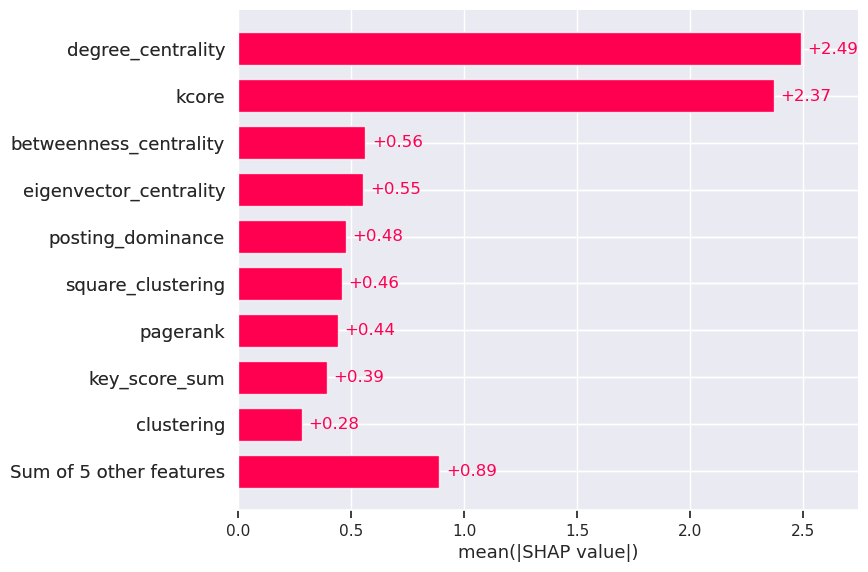

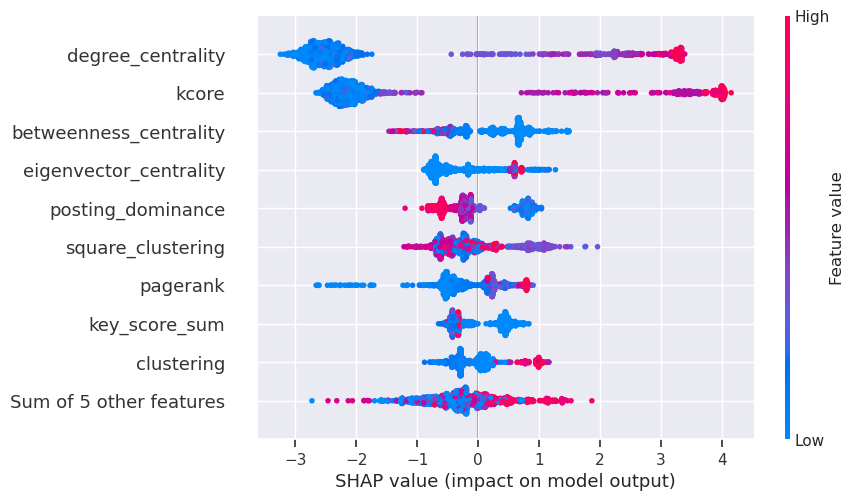

2026-04-30 11:32:52 | Completed: plot_shap_analysis


In [79]:
if run_demo:
    print("SHAP analysis for XGBoost model:")
    plot_shap_analysis(xgb_model, node_indicators_df)

# Hypothesis

## Utils

In [87]:
def build_io_rate_by_indicator(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    indicator_col: str,
    n_bins: int | None = None,
) -> pd.DataFrame:
    """Compute IO rate statistics per indicator value or bin.

        This function aggregates authors by a given indicator and computes:
        total authors, number of IO authors, IO rate, and non-IO authors.

        Args:
            node_indicators_df (pd.DataFrame):
                DataFrame indexed by account ID containing indicator columns.
            io_authors_set (set):
                Set of account IDs labeled as IO authors.
            indicator_col (str):
                Name of the indicator column to analyze.
            n_bins (int | None, optional):
                Number of quantile-based bins. If None, uses raw indicator values.

        Returns:
            pd.DataFrame:
                DataFrame with the following columns:
                    - indicator_col: Indicator value or bin midpoint.
                    - n_authors: Total number of authors in group.
                    - io_authors: Number of IO authors in group.
                    - io_rate: Fraction of IO authors (io_authors / n_authors).
                    - legitimate_authors: Number of non-IO authors.
        """
    if indicator_col not in node_indicators_df.columns:
        raise KeyError(f"{indicator_col} not found")

    # Build minimal dataframe
    df = node_indicators_df[[indicator_col]].copy()

    # IO label
    io_authors_set = set(map(str, io_authors_set))
    df["io_status"] = df.index.astype(str).isin(io_authors_set).astype(int)

    # Optional binning
    if n_bins is not None:
        # df[indicator_col] = pd.qcut(df[indicator_col], q=n_bins, duplicates="drop")
        df[indicator_col] = pd.cut(df[indicator_col], bins=n_bins, duplicates="drop")

    # Group by indicator and compute IO rate
    indicator_io_df = (
        df.groupby(indicator_col)["io_status"]
        .agg(n_authors="count", io_authors="sum", io_rate="mean")
        .reset_index()
        .sort_values(indicator_col)
    )
    indicator_io_df["legitimate_authors"] = indicator_io_df["n_authors"] - indicator_io_df["io_authors"]


    if n_bins is not None:
        indicator_io_df[indicator_col + "_bin"] = indicator_io_df[indicator_col]
        indicator_io_df[indicator_col] = indicator_io_df[indicator_col].apply(lambda x: x.mid)


    display(indicator_io_df)

    return indicator_io_df

In [81]:
@report_done
def plot_io_counts_by_indicator(
    indicator_io_df: pd.DataFrame,
    indicator_col: str,
    output_path: Path | str | None = None,
    used_bins: bool = False,
    graph_type: str = "line",
) -> None:
    """Plot total, IO, and legitimate authors by indicator.
    Args:        
        indicator_io_df: DataFrame with columns [indicator_col, n_authors, io_authors, io_rate].
        indicator_col: Column name for the indicator (x-axis).
        output_path: Optional path to save the plot image.
        used_bins: Whether the indicator_col is binned. For the title and x-axis label formatting.
        graph_type: Type of graph to plot ("line" or "bar").
    """

    if graph_type not in ["line", "bar"]:
        raise ValueError(f"Unsupported graph_type: {graph_type}. Supported: 'line', 'bar'")

    x = indicator_io_df[indicator_col]


    plt.figure(figsize=(8, 4))

    if graph_type == "line":
        # total
        plt.plot(
            x,
            indicator_io_df["n_authors"],
            marker="o",
            label="Total authors",
        )

        # io
        plt.plot(
            x,
            indicator_io_df["io_authors"],
            marker="o",
            label="IO authors",
        )

        # legitimate
        plt.plot(
            x,
            indicator_io_df["legitimate_authors"],
            marker="o",
            label="Legitimate authors",
        )

    
    if graph_type == "bar":

        plt.xticks(x)

        # total
        plt.bar(
            x,
            indicator_io_df["n_authors"],
            label="Total authors",
            color= "tab:blue",
        )

        # io
        plt.bar(
            x,
            indicator_io_df["io_authors"],
            label="IO authors",
            color= "tab:orange",
        )

    plt.xlabel(indicator_col + ("" if not used_bins else  " (middle value of bin)"))
    plt.ylabel("Number of authors")
    plt.title(f"Author Counts by {indicator_col}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        file_path = output_path / f"io_counts_by_{indicator_col}.png"
        plt.savefig(file_path, dpi=300)
        print(f"Saved fig to: {file_path}")

    plt.show()
    plt.close()

In [ ]:
from matplotlib.lines import Line2D

@report_done
def plot_io_rate_by_indicator(
    io_rate_df: pd.DataFrame,
    indicator_col: str,
    min_support: int = 1,
    output_path: Path | str | None = None,
    used_bins: bool = False,
    graph_type: str = "line",
) -> None:
    """
    Plot IO rate as a function of an indicator.

    Args:
        io_rate_df (pd.DataFrame):
            DataFrame containing aggregated statistics with columns:
            [indicator_col, n_authors, io_authors, io_rate].
        indicator_col (str):
            Name of the indicator column to plot on the x-axis.
        min_support (int):
            Minimum number of authors required for a group to be included.
        output_path (str | Path | None, optional):
            Path to save the plot image. If None, the plot is not saved.
        used_bins (bool):
            Whether the indicator values are binned. Affects axis labeling and title.
        graph_type (str):
            Type of plot to generate. Supported values: "line" or "bar".

    Returns:
        None:
            Displays the plot and optionally saves it to disk.
    """

    print(f"[plot_io_rate_by_indicator] Plotting {len(io_rate_df):,} samples with at least {min_support} authors each.")
    
    if graph_type not in ["line", "bar"]:
        raise ValueError(f"Unsupported graph_type: {graph_type}. Supported: 'line', 'bar'")

    # filter small groups
    df_plot = io_rate_df[io_rate_df["n_authors"] >= min_support]

    # sort values
    df_plot = df_plot.sort_values(indicator_col)


    plt.figure(figsize=(8, 4))

    if graph_type == "line":
        # plt.plot(
        #     df_plot[indicator_col],
        #     df_plot["io_rate"],
        #     marker="o",
        #     color="black",
        # )
        
        plt.scatter(
            df_plot[indicator_col],
            df_plot["io_rate"],
            s=20 + df_plot["n_authors"] * 2,  # size by support
            color="navy",
            zorder=3, # dots on top of the line
        )

        plt.plot(
            df_plot[indicator_col],
            df_plot["io_rate"],
            color="black",
            linewidth=0.8,
            alpha=0.5,
        )


        legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="navy",
            markersize=6,
            label="Point size ∝ number of authors",
        ),
        Line2D(
            [0], [0],
            color="none",
            label=f"Plotting groups with ≥ {min_support} authors",
        ),
        ]

        plt.legend(handles=legend_elements, loc="best")

    else: # graph_type == "bar"
        plt.bar(
            df_plot[indicator_col],
            df_plot["io_rate"],
            color="black",
        )
        
        plt.xticks(df_plot[indicator_col])


    plt.xlabel(indicator_col + ("" if not used_bins else  " (middle value of bin)"))
    plt.ylabel("IO rate")
    plt.title(f"IO Rate by {indicator_col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        file_path = output_path / f"io_rate_by_{indicator_col}.png"
        plt.savefig(file_path, dpi=300)
        print(f"Saved fig to: {file_path}")

    plt.show()
    plt.close()

## H1 (Embedding Hypothesis):
* IO drivers are more likely to appear in densely connected regions of the co-action graph.
* Evaluation: Compare IO rate across k-core / k-shell levels.
* Statistical test: Binomial Logistic Regression (Wald test on coefficient).

In [83]:
# @report_done
# def plot_indicator_histogram(
#     node_indicators_df: pd.DataFrame,
#     indicator_col: str,
#     io_authors_set: set,
#     log_scale: bool = False,
#     output_path: Path | str | None = None,
#     used_bins: bool = False,
# ) -> None:
#     """
#     Plot histogram of an indicator for total, IO, and legitimate authors.
#     Args:        
#         node_indicators_df: DataFrame indexed by author IDs, with indicator columns.
#         indicator_col: Column name of the indicator to plot.
#         io_authors_set: Set of author IDs labeled as IO.
#         log_scale: Whether to use logarithmic scale for y-axis.
#         output_path: Optional path to save the plot image.
#         used_bins: Whether the indicator_col is binned. For the title and x-axis label formatting.
#     """

#     if indicator_col not in node_indicators_df.columns:
#         raise KeyError(f"{indicator_col} not found")

#     df = node_indicators_df.copy()

#     # IO label
#     io_authors_set = set(map(str, io_authors_set))
#     df["io_status"] = df.index.astype(str).isin(io_authors_set)

#     total = df[indicator_col].dropna()
#     io_vals = df.loc[df["io_status"], indicator_col].dropna()
#     legit_vals = df.loc[~df["io_status"], indicator_col].dropna()

#     plt.figure(figsize=(8, 4))

#     # Total
#     plt.hist(
#         total,
#         color="tab:blue",
#         alpha=0.5,
#         label="Total authors",
#     )

#     # Legitimate
#     plt.hist(
#         legit_vals,
#         color="tab:green",
#         alpha=0.5,
#         label="Legitimate authors",
#     )

#     # IO
#     plt.hist(
#         io_vals,
#         color="tab:orange",
#         alpha=0.5,
#         label="IO authors",
#     )

#     plt.xlabel(indicator_col + (" (value)" if not used_bins else " (binned)"))
#     plt.ylabel("Number of authors" + (" (log scale)" if log_scale else ""))
#     plt.title(f"{indicator_col} Distribution")

#     if log_scale:
#         plt.yscale("log")

#     plt.legend()
#     plt.tight_layout(rect=[0, 0, 0.85, 1])

#     if output_path is not None:
#         output_path = Path(output_path)
#         file_path = output_path / f"{indicator_col}_distribution.png"
#         plt.savefig(file_path, dpi=300)
#         print(f"Saved fig to: {file_path}")

#     plt.show()
#     plt.close()

In [84]:
import statsmodels.formula.api as smf

def logit_statistical_test(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    indicator_col: str,
):
    """
    Perform a logistic regression to test the relationship between an indicator and IO status.
    Used for categorical dependent variable and numeric independent variable.
    Args:
        node_indicators_df: DataFrame indexed by author IDs, with indicator columns.
        io_authors_set: Set of author IDs labeled as IO.
        indicator_col: Column name of the indicator to test.

    Returns:
        logit_model: Fitted logistic regression model.
        summery: Summary of the logistic regression model.
    """

    if indicator_col not in node_indicators_df.columns:
        raise KeyError(f"{indicator_col} not found")

    indicators_df = node_indicators_df[[indicator_col]].copy()
    io_authors_set = set(map(str, io_authors_set))
    indicators_df["io_status"] = indicators_df.index.astype(str).isin(io_authors_set).astype(int)

    logit_model = smf.logit(f"io_status ~ {indicator_col}", data=indicators_df).fit(disp=False)
    summery = logit_model.summary()

    print(summery)

    return logit_model, summery

,kcore,n_authors,io_authors,io_rate,legitimate_authors
0,1,38,0,0.000000,38
1,2,53,0,0.000000,53
2,3,60,1,0.016667,59
3,4,46,0,0.000000,46
4,5,34,0,0.000000,34
...,...,...,...,...,...
130,197,1,1,1.000000,0
131,198,1,1,1.000000,0
132,214,4,4,1.000000,0
133,215,1,1,1.000000,0


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_counts_by_kcore.png


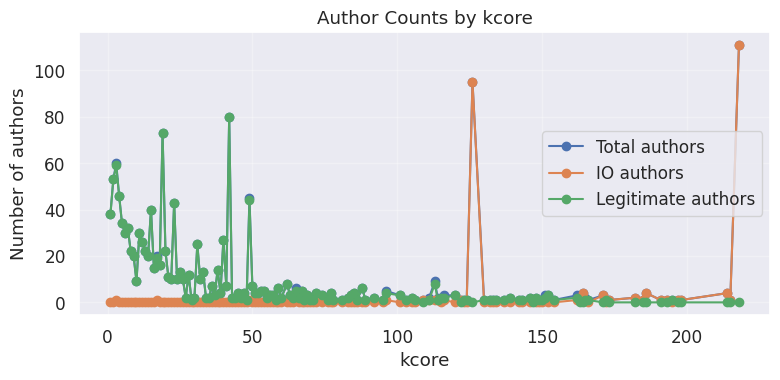

2026-04-30 12:07:10 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 135 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_rate_by_kcore.png


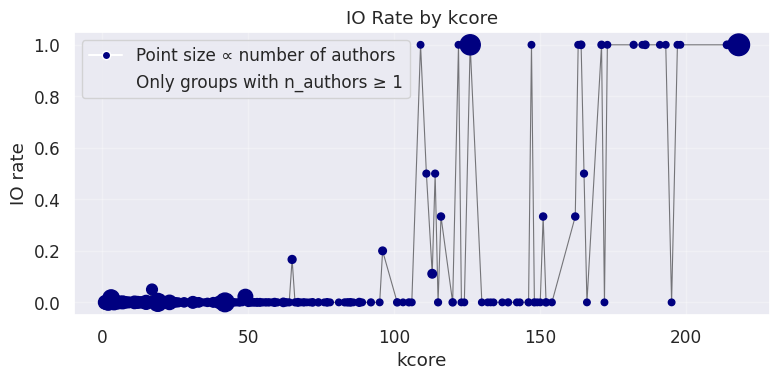

2026-04-30 12:07:10 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1403
Model:                          Logit   Df Residuals:                     1401
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.7608
Time:                        12:07:10   Log-Likelihood:                -155.79
converged:                       True   LL-Null:                       -651.34
Covariance Type:            nonrobust   LLR p-value:                1.537e-217
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.8409      0.490    -13.957      0.000      -7.802      -5.880
kcore          0.0581      0.004     13.682      0.000       0.050      

In [123]:
if run_demo:
    indicator_col = "kcore"
    n_bins = None

    used_bins = n_bins is not None
    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col, n_bins = n_bins)

    
    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1,"kcore",folder_output_path, used_bins)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col, output_path = folder_output_path, used_bins = used_bins)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col)

,kcore,n_authors,io_authors,io_rate,legitimate_authors,kcore_bin
0,6.3165,374,1,0.002674,373,"(0.783, 11.85]"
1,17.2750,275,1,0.003636,274,"(11.85, 22.7]"
2,28.1250,141,0,0.000000,141,"(22.7, 33.55]"
3,38.9750,150,0,0.000000,150,"(33.55, 44.4]"
4,49.8250,83,1,0.012048,82,"(44.4, 55.25]"
5,60.6750,36,1,0.027778,35,"(55.25, 66.1]"
6,71.5250,19,0,0.000000,19,"(66.1, 76.95]"
7,82.3750,16,0,0.000000,16,"(76.95, 87.8]"
8,93.2250,15,1,0.066667,14,"(87.8, 98.65]"
9,104.0750,8,1,0.125000,7,"(98.65, 109.5]"


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_counts_by_kcore.png


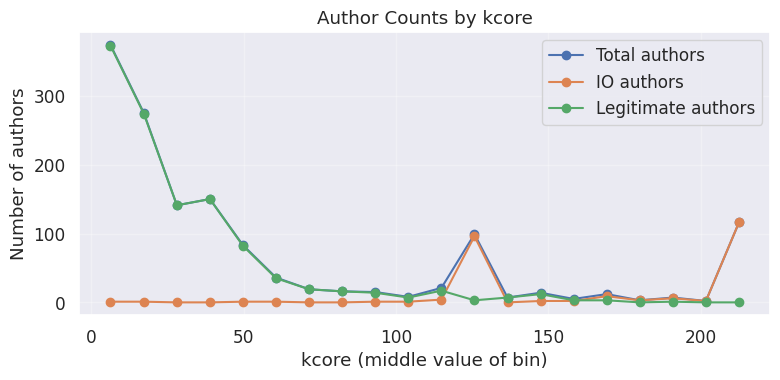

2026-04-30 12:07:23 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 20 samples with at least 5 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_rate_by_kcore.png


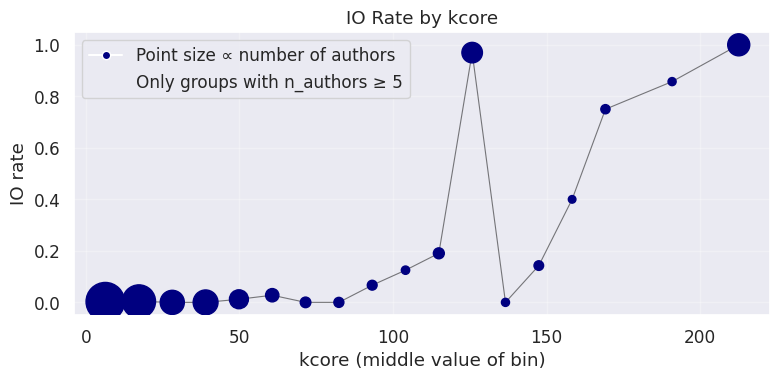

2026-04-30 12:07:23 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1403
Model:                          Logit   Df Residuals:                     1401
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.7608
Time:                        12:07:23   Log-Likelihood:                -155.79
converged:                       True   LL-Null:                       -651.34
Covariance Type:            nonrobust   LLR p-value:                1.537e-217
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.8409      0.490    -13.957      0.000      -7.802      -5.880
kcore          0.0581      0.004     13.682      0.000       0.050      

In [124]:
if run_demo:
    indicator_col = "kcore"
    n_bins = 20
    
    used_bins = n_bins is not None
    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col, n_bins = n_bins)

    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1, indicator_col="kcore", output_path=folder_output_path, used_bins = used_bins)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col, min_support= 5, output_path = folder_output_path, used_bins = used_bins)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col)

## H2 (Community Heterogeneity Hypothesis):
* IO drivers are non-uniformly distributed across communities in the co-action graph.
* Evaluation: Compare IO driver probability across different communities.
* Statistical test: permutation-based chi-square test of homogeneity.
    * Dependent variable: IO status (categorial, 0/1).
    * Independent variable: community membership (categorial).

In [125]:
from scipy.stats import chi2_contingency


def permutation_chi2_test(
    node_indicators_df: pd.DataFrame,
    indicator_col: str,
    io_authors_set: set,
    n_permutations: int = 1000,
    random_state: int | None = None,
    alpha: float = 0.05
) -> dict:
    """Permutation-based chi-square test of homogeneity.
    Used for categorical Dependent variable and categorical independent variable.

    Args:
        node_indicators_df (pd.DataFrame):
            DataFrame where index are account IDs and columns include the indicator.
        indicator_col (str):
            Column with indicator values (categorical).
        io_authors_set (set):
            Set of IO author IDs.
        n_permutations (int, optional):
            Number of permutations. Defaults to 1000.
        random_state (int | None, optional):
            Random seed for reproducibility. Defaults to None.
        alpha (float, optional):
            Significance level for hypothesis testing. Defaults to 0.05.

    Returns:
        dict:
            {
                "observed_chi2": float,
                "p_value": float,
                "perm_distribution": np.ndarray
            }
    """
    
    # target_values
    io_authors_set = set(map(str, io_authors_set))
    target_values = node_indicators_df.index.astype(str).isin(io_authors_set).astype(int) 

    # Observed contingency table
    observed_table = pd.crosstab(index = node_indicators_df[indicator_col], columns = target_values)
    observed_chi2, _, _, _ = chi2_contingency(observed_table)

    perm_statistics = np.zeros(n_permutations)


    rng = np.random.default_rng(random_state)
    # Permutation loop
    for i in range(n_permutations):
        rng.shuffle(target_values)  # permute labels

        perm_table = pd.crosstab(index = node_indicators_df[indicator_col], columns = target_values)

        # Align shape
        perm_table = perm_table.reindex_like(observed_table).fillna(0).astype(int)
        
        perm_chi2, _, _, _ = chi2_contingency(perm_table)
        perm_statistics[i] = perm_chi2

    # Empirical p-value
    p_value = (np.sum(perm_statistics >= observed_chi2) + 1) / (n_permutations + 1)


    # print results
    reject = p_value < alpha

    print("\n=== Permutation Chi-Square Test Summary ===")
    print(f"Indicator: {indicator_col}")
    print("Target: IO status (0/1)")
    print(f"Number of permutations: {n_permutations:,}")
    print(f"Observed chi-square: {observed_chi2:.4f}")
    print(f"Empirical p-value: {p_value:.4f}")
    print(f"Significance level (alpha): {alpha}")

    print("\nHypotheses:")
    print(f"H0: Target is independent of the {indicator_col} (uniform distribution across groups).")
    print(f"H1: Target distribution differs across {indicator_col} groups.")

    print("\nConclusion:")
    if reject:
        print("Reject H0 → Evidence of non-uniform distribution (heterogeneity).")
    else:
        print("Fail to reject H0 → No strong evidence of heterogeneity.")

    return {
        "observed_chi2": observed_chi2,
        "p_value": p_value,
        "perm_distribution": perm_statistics,
    }

,louvain_community,n_authors,io_authors,io_rate,legitimate_authors
0,0,128,82,0.640625,46
1,1,3,0,0.000000,3
2,2,133,53,0.398496,80
3,3,665,106,0.159398,559
4,4,3,0,0.000000,3
5,5,16,3,0.187500,13
6,6,404,2,0.004950,402
7,7,6,0,0.000000,6
8,8,2,0,0.000000,2
9,9,2,0,0.000000,2


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_counts_by_louvain_community.png


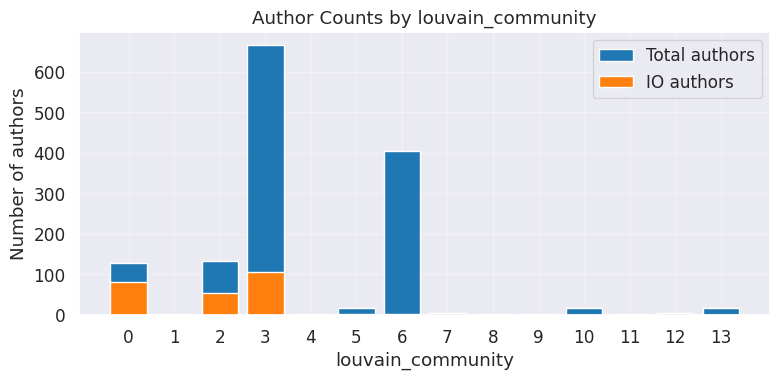

2026-04-30 12:07:56 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 14 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_rate_by_louvain_community.png


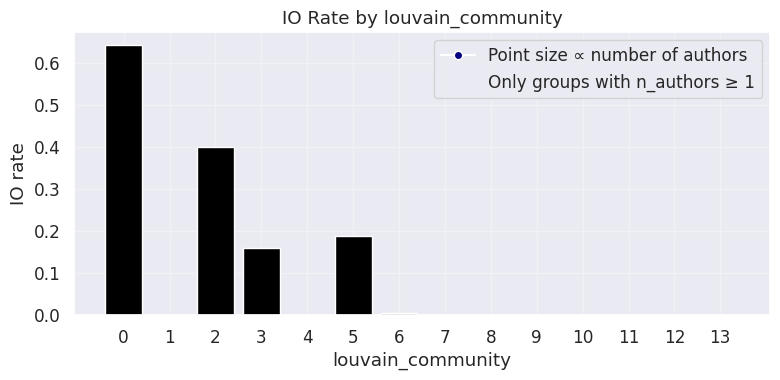

2026-04-30 12:07:56 | Completed: plot_io_rate_by_indicator

=== Permutation Chi-Square Test Summary ===
Indicator: louvain_community
Target: IO status (0/1)
Number of permutations: 1,000
Observed chi-square: 331.8712
Empirical p-value: 0.0010
Significance level (alpha): 0.05

Hypotheses:
H0: Target is independent of the louvain_community (uniform distribution across groups).
H1: Target distribution differs across louvain_community groups.

Conclusion:
Reject H0 → Evidence of non-uniform distribution (heterogeneity).


In [126]:
if run_demo:
    indicator_col_H2 = "louvain_community"

    indicator_io_df_H2  = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_H2)

    plot_io_counts_by_indicator(indicator_io_df_H2, indicator_col_H2, folder_output_path, used_bins = False, graph_type="bar")
    plot_io_rate_by_indicator(indicator_io_df_H2, indicator_col_H2, min_support= 1, output_path = folder_output_path, graph_type="bar")
    permutation_chi2_test(node_indicators_df, indicator_col_H2, io_authors_set=io_authors_set)

,top_topic,n_authors,io_authors,io_rate,legitimate_authors
0,-1,28,0,0.000000,28
1,0,298,116,0.389262,182
2,1,37,0,0.000000,37
3,2,39,0,0.000000,39
4,3,40,12,0.300000,28
5,4,37,1,0.027027,36
6,5,41,0,0.000000,41
7,6,16,0,0.000000,16
8,7,13,0,0.000000,13
9,8,16,0,0.000000,16


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_counts_by_top_topic.png


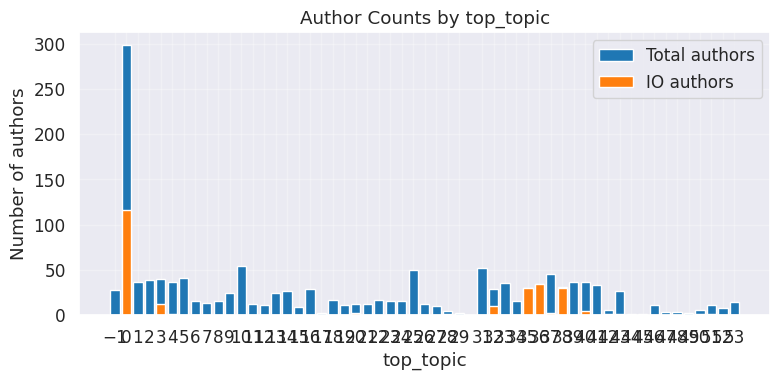

2026-04-30 12:08:01 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 54 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_30/io_rate_by_top_topic.png


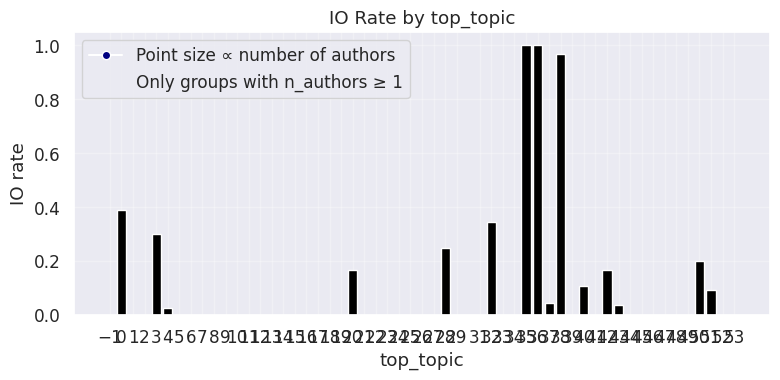

2026-04-30 12:08:01 | Completed: plot_io_rate_by_indicator

=== Permutation Chi-Square Test Summary ===
Indicator: top_topic
Target: IO status (0/1)
Number of permutations: 1,000
Observed chi-square: 717.3786
Empirical p-value: 0.0010
Significance level (alpha): 0.05

Hypotheses:
H0: Target is independent of the top_topic (uniform distribution across groups).
H1: Target distribution differs across top_topic groups.

Conclusion:
Reject H0 → Evidence of non-uniform distribution (heterogeneity).


In [127]:
if run_demo:
    indicator_col_H2 = "top_topic"

    indicator_io_df_H2  = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_H2)

    plot_io_counts_by_indicator(indicator_io_df_H2, indicator_col_H2, folder_output_path, used_bins = False, graph_type="bar")
    plot_io_rate_by_indicator(indicator_io_df_H2, indicator_col_H2, min_support= 1, output_path = folder_output_path, graph_type="bar")
    permutation_chi2_test(node_indicators_df, indicator_col_H2, io_authors_set=io_authors_set)

# Indicator Based Graph Filtering

In [128]:
@report_done
def filter_graph_by_indicators(
    G: nx.Graph,
    indicator_name: str,
    threshold_percentage: float = 1,
    node_indicator_dict: dict | None = None,
    key_authors_mode: str = "global",
    df: pd.DataFrame | None = None,
    topic_col: str | None = None,
    author_col: str = "accountid",
    author_score_col: str = "topic_author_key_score",
    base_number: int = 5,
) -> nx.Graph:
    """Filter graph nodes by top indicator values or per-topic key authors.

    Args:
        G: Input graph.
        indicator_name: Indicator name to use for filtering.
        threshold_percentage: Percentage of top nodes to keep, in (0, 100].
            Values in (0, 1) are treated as fractions.
        node_indicator_dict: Optional dict mapping node to indicator value.
        key_authors_mode: Filtering mode. Either "global" or "per_topic".
        df: Input dataframe, required for "per_topic" mode.
        topic_col: Topic column, required for "per_topic" mode.
        author_col: Author id column.
        author_score_col: Author score column for per-topic mode.
        base_number: Base number of authors per topic.

    Returns:
        A filtered graph containing only selected nodes.
    """
    if threshold_percentage <= 0 or threshold_percentage > 100:
        raise ValueError(
            f"threshold_percentage must be in (0, 100], got {threshold_percentage}"
        )

    if threshold_percentage < 1:
        threshold_percentage *= 100
        print(
            "[filter_graph_by_indicators] WARNING: "
            f"interpreting fraction as percentage: {threshold_percentage}%"
        )

    mode = key_authors_mode.strip().lower().replace(" ", "_")

    if mode not in {"global", "per_topic"}:
        raise ValueError(
            f"Invalid key_authors_mode={key_authors_mode!r}. "
            "Use 'global' or 'per_topic'."
        )

    if mode == "per_topic":
        if df is None:
            raise ValueError("df is required when key_authors_mode='per_topic'.")
        if topic_col is None:
            raise ValueError("topic_col is required when key_authors_mode='per_topic'.")

        selected_authors = get_all_topics_key_authors(
            df=df,
            author_score_col=author_score_col,
            author_col=author_col,
            topic_col=topic_col,
            key_authors_mode=mode,
            base_number=base_number,
            top_percentage=threshold_percentage,
        )

        graph_nodes_by_str = {str(node): node for node in G.nodes}
        nodes_to_keep = {
            graph_nodes_by_str[str(author)]
            for author in selected_authors
            if str(author) in graph_nodes_by_str
        }

    else:
        if node_indicator_dict is not None:
            print(
                f"[filter_graph_by_indicators] Using provided node_indicator_dict "
                f"for '{indicator_name}'."
            )
            raw_indicator = node_indicator_dict

        else:
            print(
                f"[filter_graph_by_indicators] Trying node attributes "
                f"for '{indicator_name}'."
            )

            raw_indicator = nx.get_node_attributes(G, indicator_name)

            if not raw_indicator:
                print(
                    f"[filter_graph_by_indicators] Node attribute '{indicator_name}' "
                    "not found. Computing indicator with _compute_indicator."
                )

                global _GRAPH
                _GRAPH = G

                _, raw_indicator, _ = _compute_indicator(indicator_name)

        indicator_by_str_node = {
            str(node): value
            for node, value in raw_indicator.items()
            if pd.notna(value)
        }

        missing_nodes = [
            node for node in G.nodes
            if str(node) not in indicator_by_str_node
        ]

        if missing_nodes:
            raise KeyError(
                f"Missing '{indicator_name}' for {len(missing_nodes):,} "
                f"nodes ({len(missing_nodes) / G.number_of_nodes():.1%})."
            )

        graph_nodes_by_str = {str(node): node for node in G.nodes}

        values = sorted(indicator_by_str_node.values(), reverse=True)
        num_to_keep = max(1, int(len(values) * threshold_percentage / 100))
        threshold_value = values[num_to_keep - 1]

        nodes_to_keep = {
            graph_nodes_by_str[node_str]
            for node_str, value in indicator_by_str_node.items()
            if value >= threshold_value
        }

    G_filtered = G.subgraph(nodes_to_keep).copy()

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    n_nodes_f = G_filtered.number_of_nodes()
    n_edges_f = G_filtered.number_of_edges()

    node_ratio = n_nodes_f / n_nodes if n_nodes else 0
    edge_ratio = n_edges_f / n_edges if n_edges else 0

    print(
        f"""[filter_graph_by_indicators]
    {indicator_name} | top {threshold_percentage}%

    Nodes: {n_nodes:,} → {n_nodes_f:,} ({node_ratio:.1%})
    Edges: {n_edges:,} → {n_edges_f:,} ({edge_ratio:.1%})
    """
    )

    return G_filtered

In [129]:
# import networkx as nx
# import pandas as pd

# folder_path = Path("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_03_29")
# G_accounts = nx.read_gexf(folder_path / "BERTopic_topic_512_accounts_graph.gexf")
# node_indicators_df = pd.read_parquet(folder_path / "node_indicators.parquet")

In [130]:
@report_done
def build_and_plot_filtered_graphs_by_indicator(
    G: nx.Graph,
    indicator_name: str,
    indicator_threshold_percentages: list[float],
    layout: str = "spring",
    folder_output_path: str | Path | None = None,
    key_authors_mode: str | None = 'global',
    df: pd.DataFrame | None = None,
    topic_col: str | None = None,
    author_col: str = "accountid",
    author_score_col: str = "topic_author_key_score",
    base_number: int = 5,
    node_indicator_dict: dict | None = None,
) -> None:
    """Filter graph by indicator thresholds and plot as subplots.

    Args:
        G: Original graph.
        indicator_name: Indicator used for filtering.
        indicator_threshold_percentages: List of thresholds (e.g., [1, 5, 10]).
        layout: Layout name for plotting.
        folder_output_path: Optional path to save plot.
        key_authors_mode: Optional key-author mode passed to filter_graph_by_indicators.
        df: DataFrame containing the data (required for 'per_topic' mode).
        topic_col: Topic column name used in per_topic mode.
        author_col: Author identifier column for key-author selection.
        author_score_col: Score column for per_topic key-author selection.
        base_number: Base number of authors per topic for per_topic mode.
        node_indicator_dict: Optional flat dict {node_id: indicator_value} passed to filtering in global mode.
    Returns:
        None. Displays and optionally saves subplot figure.
    """

    filtered_graph_name = (
        G.graph.get("name", "accounts_graph")
        + f"_filtered_by_{indicator_name}"
    )

    print(f"[plot_filtered_graphs_by_indicator] Building {len(indicator_threshold_percentages)} filtered graphs...")

    graphs = []
    sub_plot_titles = []

    for threshold in tqdm(indicator_threshold_percentages, desc="Filtering graphs"):
        sub_plot_title = f"Top {threshold}% {indicator_name}"

        G_filtered = filter_graph_by_indicators(
            G=G,
            indicator_name=indicator_name,
            threshold_percentage=threshold,
            node_indicator_dict=node_indicator_dict,
            key_authors_mode=key_authors_mode,
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            author_score_col=author_score_col,
            base_number=base_number,
        )

        graphs.append(G_filtered)
        sub_plot_titles.append(sub_plot_title)

    print(f"[plot_filtered_graphs_by_indicator] Plotting {len(graphs)} filtered graphs by indicator '{indicator_name}' with layout '{layout}'...")

    plot_accounts_graph(
        G=graphs,
        title=sub_plot_titles,
        graph_name=filtered_graph_name,
        folder_output_path=folder_output_path,
        layout=layout,
    )

## Runing

### Parameters

In [131]:
if run_demo:
        
    layout_name_for_filtered_graph = "spring"
    indicator_name_for_filtering = "kcore"
    indicator_threshold_percentages = [100, 50, 25, 10]

    folder_output_path_for_filtered_graph = folder_output_path / f"graphs_filtered_by_{indicator_name_for_filtering}"
    folder_output_path_for_filtered_graph.mkdir(exist_ok=True)

    print(f"Filtering graph by indicator '{indicator_name_for_filtering}' with thresholds: {indicator_threshold_percentages}%")
    print(f"topic col = {topic_col}")
    print("For KeyScore Filtering, key mode is 'per_topic' and for k-core filtering, key mode is 'global'.")

Filtering graph by indicator 'kcore' with thresholds: [100, 50, 25, 10]%
topic col = BERTopic_topic_256
For KeyScore Filtering, key mode is 'per_topic' and for k-core filtering, key mode is 'global'.


### Utils

In [ ]:
if run_demo:
    
    G_no_filtering = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors_set,
        # all_topics_key_authors_set=all_topics_key_authors_set, # not using filtering
        author_topic_key_score_df=author_topic_key_score_df,  # for node labels.
        boost_score_df=boost_df,
        is_directed_graphs= False,
        topic_col=topic_col,
        author_col=account_id_col,
        graph_name="accounts_graph_no_filtering",
    )


    # node_indicator_G_no_filtering = compute_indicators(G_no_filtering, folder_output_path)

### Only KeyScore Filtering

In [ ]:
# only KeyScore filtering (per topic)

if run_demo:

    print("only KeyScore filtering")

    build_and_plot_filtered_graphs_by_indicator(
        G=G_no_filtering,
        indicator_name=author_key_score_col, # topic_author_key_score
        indicator_threshold_percentages=indicator_threshold_percentages,
        layout=layout_name_for_filtered_graph,
        folder_output_path=folder_output_path_for_filtered_graph,
        key_authors_mode='per_topic',
        df=df,
        topic_col=topic_col,
        author_col=account_id_col,
        author_score_col=author_key_score_col,
    )

only KeyScore filtering
[plot_filtered_graphs_by_indicator] Building 4 filtered graphs...


Filtering graphs:   0%|          | 0/4 [00:00<?, ?it/s]

[get_all_topics_key_authors] WARNING: top_percentage 100 is >= 1. Interpreting as 10000.00%.
2026-04-30 12:51:45 | [get_all_topics_key_authors] top_percentage is 100%, so all authors will be selected as key authors.
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 100.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 21,923 unique key/boost authors in all topics.
2026-04-30 12:51:45 | Completed: get_all_topics_key_authors


Filtering graphs:  25%|██▌       | 1/4 [00:04<00:12,  4.33s/it]

[filter_graph_by_indicators]
    topic_author_key_score | top 100%

    Nodes: 295,125 → 21,787 (7.4%)
    Edges: 1,507,698 → 872,947 (57.9%)
    
2026-04-30 12:51:49 | Completed: filter_graph_by_indicators
[get_all_topics_key_authors] WARNING: top_percentage 50 is >= 1. Interpreting as 5000.00%.
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 50.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 19,081 unique key/boost authors in all topics.
2026-04-30 12:51:49 | Completed: get_all_topics_key_authors


...

[filter_graph_by_indicators]
    topic_author_key_score | top 50%

    Nodes: 295,125 → 19,019 (6.4%)
    Edges: 1,507,698 → 817,021 (54.2%)
    
2026-04-30 12:51:53 | Completed: filter_graph_by_indicators
[get_all_topics_key_authors] WARNING: top_percentage 25 is >= 1. Interpreting as 2500.00%.
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 25.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 14,068 unique key/boost authors in all topics.
2026-04-30 12:51:53 | Completed: get_all_topics_key_authors


Filtering graphs:  75%|███████▌  | 3/4 [00:11<00:03,  3.59s/it]

[filter_graph_by_indicators]
    topic_author_key_score | top 25%

    Nodes: 295,125 → 14,038 (4.8%)
    Edges: 1,507,698 → 638,325 (42.3%)
    
2026-04-30 12:51:56 | Completed: filter_graph_by_indicators
[get_all_topics_key_authors] WARNING: top_percentage 10 is >= 1. Interpreting as 1000.00%.
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 10.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 7,557 unique key/boost authors in all topics.
2026-04-30 12:51:56 | Completed: get_all_topics_key_authors


Filtering graphs: 100%|██████████| 4/4 [00:13<00:00,  3.27s/it]

[filter_graph_by_indicators]
    topic_author_key_score | top 10%

    Nodes: 295,125 → 7,544 (2.6%)
    Edges: 1,507,698 → 330,168 (21.9%)
    
2026-04-30 12:51:58 | Completed: filter_graph_by_indicators
[plot_filtered_graphs_by_indicator] Plotting 4 filtered graphs by indicator 'topic_author_key_score' with layout 'spring'...
[plot_accounts_graph] Plotting graph with 21787 nodes: 21010 legitimate authors, 777 IO authors, IO percentage: 3.6%
[plot_accounts_graph] Layout: spring


### Only k-core Filtering

In [ ]:
if run_demo:

    print("only k-core filtering")

    build_and_plot_filtered_graphs_by_indicator(
        G=G_no_filtering,
        indicator_name=indicator_name_for_filtering, # "kcore"
        indicator_threshold_percentages=indicator_threshold_percentages,
        layout=layout_name_for_filtered_graph,
        folder_output_path=folder_output_path_for_filtered_graph,
    )

### KeyScore Filtering --> k-core Filtering

In [ ]:
if run_demo:

    print("only k-core filtering")

    print(f"Top key authors percentage = {top_percentage}")

    build_and_plot_filtered_graphs_by_indicator(
        G=G_accounts,
        indicator_name=indicator_name_for_filtering, # "kcore"
        indicator_threshold_percentages=indicator_threshold_percentages,
        layout=layout_name_for_filtered_graph,
        folder_output_path=folder_output_path_for_filtered_graph,
    )

### k-core Filtering --> KeyScore Filtering

In [ ]:
threshold_percentage_k_core = 10

print(f"threshold_percentage_k_core = {threshold_percentage_k_core}")


G_k_core_filtered = filter_graph_by_indicators(
    G=G_no_filtering,
    indicator_name = indicator_name_for_filtering, # "kcore"
    threshold_percentage=threshold_percentage_k_core,
)


build_and_plot_filtered_graphs_by_indicator(
    G=G_k_core_filtered,
    indicator_name=author_key_score_col, # topic_author_key_score
    indicator_threshold_percentages=indicator_threshold_percentages,
    layout=layout_name_for_filtered_graph,
    folder_output_path=folder_output_path_for_filtered_graph,
    key_authors_mode='per_topic',
    df=df,
    topic_col=topic_col,
    author_col=account_id_col,
    author_score_col=author_key_score_col,
)

# Parameter Sweep: Information Gain and AUC Analysis

This section implements functions to run key_authors_graph with different min_topic_size, top_percentage, and key_authors_mode values, compute total information gain, and visualize the results.

In [ ]:
from itertools import product
from typing import Iterable, Sequence

from concurrent.futures import ProcessPoolExecutor
import os


import gc # garbage collector

## One Experiment

In [ ]:
def run_io_indicator_ig_experiment(
    df: pd.DataFrame,
    topic_col: str,
    top_percentage: float,
    account_relations: Iterable[tuple[str, str]],
    is_directed_graphs: bool,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    key_authors_mode: str = "per_topic",
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"],
    author_topic_key_score_df: pd.DataFrame | None = None, # (rows = authors, columns = topics, values = author-topic score)
    io_authors_set: set | None = None, # set of authors that are labeled as IO. If not provided, it will be computed.
    boost_score_df: pd.DataFrame | None = None, # Optional DataFrame with columns [accountid, boost_score].
) -> pd.DataFrame:
    """Run a full IO experiment pipeline and return summary metrics.

    Pipeline:
      1) Use the provided topic_col
      2) get_io_authors_by_ratio(...) -> io_authors
      3) get_all_topics_key_authors(...) -> all_topics_key_authors_set
      4) Boost authors: merge boost_authors_set into all_topics_key_authors_set (if boost_score_df provided)
      5) build_accounts_graph(...) -> G
      6) compute_indicators(G) -> node_indicators_df
      7) compute_centrality_information_gain(...) -> IG per indicator (for both key_authors and all_authors variants)
      8) compute AUC for RF, XGBoost, and Logistic Regression on node indicators (for both key_authors and all_authors variants)
      9) return IG + AUC summary metrics.

    Returns:
        Single-row DataFrame with topic_col, top_percentage,
        key_authors_mode, is_directed_graphs, IG and AUC metrics for both
        key_authors and all_authors variants, and helpful counts.
    """
    mode = key_authors_mode.strip().lower().replace(" ", "_")
    assert mode in ("per_topic", "global"), (
        f"Invalid key_authors_mode: {key_authors_mode!r}. Use 'per_topic' or 'global'."
    )

    if topic_col not in df.columns:
        raise KeyError(f"[MY ERROR] topic_col '{topic_col}' not found in df.columns")

    # ---------- 1) IO authors ----------
    if io_authors_set is None:
        io_authors_set = get_io_authors_by_ratio(
            df=df,
            author_col=author_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
        )
        io_authors_set = set(map(str, io_authors_set))

    # ---------- 2) key authors ----------

    post_score_col = f"post_tfidf_{topic_col}"
    author_score_col = f"topic_author_key_score_{topic_col}"


    if post_score_col not in df.columns:
        print(f"Computing post-level TF-IDF scores for topic_col '{topic_col}' and saving to column '{post_score_col}'")
        compute_post_tfidf(df, topic_col, entity_cols_lst, post_score_col)

    to_delate_author_topic_key_score_df = False
    if author_score_col not in df.columns or author_topic_key_score_df is None:
        print(f"[run_io_indicator_ig_experiment] Computing author-topic key scores for topic_col '{topic_col}' and saving to column '{author_score_col}'")
        # author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)
        author_topic_key_score_df = compute_author_key_score(
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            post_score_col=post_score_col,
            author_score_col=author_score_col,
        )
        to_delate_author_topic_key_score_df =  True

    all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        author_score_col=author_score_col,
        author_col=author_col,
        topic_col=topic_col,
        key_authors_mode=mode,
        base_number=10,
        top_percentage=top_percentage,
    )


    # ---------- 3) Boost authors ----------
    if boost_score_df is not None:
        # Boost scores are global (not topic-specific), so use global mode.
        boost_authors_set = get_all_topics_key_authors(
            df=boost_score_df,
            author_score_col="boost_score",
            author_col=author_col,
            topic_col=None,
            key_authors_mode="global",
            base_number=10,
            top_percentage=top_percentage,
        )
        # Merge boost authors into key authors set so both are included in the graph.
        all_topics_key_authors_set = all_topics_key_authors_set.union(boost_authors_set)


    # ---------- 4) build graph ----------
    G = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors_set,
        all_topics_key_authors_set=all_topics_key_authors_set,
        author_topic_key_score_df=author_topic_key_score_df,  # for node labels.
        boost_score_df=boost_score_df,
        is_directed_graphs=is_directed_graphs,
        topic_col=topic_col,
        author_col=author_col,
    )

    # ---------- 5) compute indicators ----------
    node_indicators_df = compute_indicators(G)

    # ---------- 6) Preparation ----------
    all_authors = df[author_col].astype(str).unique()
    node_indicators_df_all_authors = add_missing_authors_with_zeros(node_indicators_df, all_authors)

    # ---------- 7) IG - key authors variant ----------
    ig_series_key_authors = compute_indicators_information_gain(node_indicators_df, io_authors_set)

    ig_series_key_authors = pd.to_numeric(ig_series_key_authors, errors="coerce").dropna()

    ig_sum_key_authors = float(ig_series_key_authors.sum())
    ig_mean_key_authors = float(ig_series_key_authors.mean())

    # ---------- 7) IG - all authors variant ----------
    ig_series_all_authors = compute_indicators_information_gain(node_indicators_df_all_authors,io_authors_set)

    ig_series_all_authors = pd.to_numeric(ig_series_all_authors, errors="coerce").dropna()

    ig_sum_all_authors = float(ig_series_all_authors.sum())
    ig_mean_all_authors = float(ig_series_all_authors.mean())

    # ---------- 8) AUC - key authors variant ----------
    auc_rf_key_authors = io_classification(node_indicators_df, io_authors_set, "random_forest", folder_output_path)[2] # save only auc
    auc_xgb_key_authors = io_classification(node_indicators_df, io_authors_set, "xgboost", folder_output_path)[2] # save only auc
    auc_lr_key_authors = io_classification(node_indicators_df, io_authors_set, "logistic_regression", folder_output_path)[2] # save only auc

    auc_best_key_authors = max(auc_rf_key_authors, auc_xgb_key_authors, auc_lr_key_authors)

    # ---------- 8) AUC - all authors variant ----------
    auc_rf_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "random_forest", folder_output_path)[2] # save only auc
    auc_xgb_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "xgboost", folder_output_path)[2] # save only auc
    auc_lr_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "logistic_regression", folder_output_path)[2] # save only auc

    auc_best_all_authors = max(auc_rf_all_authors, auc_xgb_all_authors, auc_lr_all_authors)

    # ---------- 9) Memory Clean ----------

    n_indicators = len(ig_series_key_authors)
    n_io_authors = len(io_authors_set)
    n_nodes = node_indicators_df.shape[0]

    del G
    del node_indicators_df
    del node_indicators_df_all_authors
    del ig_series_key_authors
    del ig_series_all_authors
    del all_topics_key_authors_set
    if to_delate_author_topic_key_score_df: # created in this function
        del author_topic_key_score_df
    gc.collect()

    # ---------- output ----------
    return pd.DataFrame([{
        "topic_col": topic_col,
        "top_percentage": float(top_percentage),
        "key_authors_mode": mode,
        "is_directed_graphs": bool(is_directed_graphs),
        "ig_sum_key_authors": ig_sum_key_authors,
        "ig_mean_key_authors": ig_mean_key_authors,
        "ig_sum_all_authors": ig_sum_all_authors,
        "ig_mean_all_authors": ig_mean_all_authors,
        "auc_rf_key_authors": auc_rf_key_authors,
        "auc_xgb_key_authors": auc_xgb_key_authors,
        "auc_lr_key_authors": auc_lr_key_authors,
        "auc_best_key_authors": auc_best_key_authors,
        "auc_rf_all_authors": auc_rf_all_authors,
        "auc_xgb_all_authors": auc_xgb_all_authors,
        "auc_lr_all_authors": auc_lr_all_authors,
        "auc_best_all_authors": auc_best_all_authors,
        "n_indicators": int(n_indicators),
        "n_nodes": int(n_nodes),
        "n_io_authors": int(n_io_authors),
        "n_account_relations": int(len(account_relations)),
    }])

## Grid Experiments

In [ ]:
def get_author_topic_key_score_dict(
    df: pd.DataFrame,
    topic_cols: list[str],
    author_col: str,
    entity_cols_lst: list[str],
) -> dict[str, pd.DataFrame]:
    """Compute author-topic key score matrices for multiple topic columns.

    Ensures TF-IDF and author-topic score columns exist in df, then returns
    a dict mapping each topic_col -> author_topic_key_score_df.

    Args:
        df: Posts DataFrame (modified in place if score columns are missing).
        topic_cols: List of topic column names.
        author_col: Author column name.
        entity_cols_lst: Entity columns used for TF-IDF.

    Returns:
        Dict mapping topic_col -> author_topic_key_score_df.
    """
    
    # {topic_col, author_topic_key_score_df}
    out: dict[str, pd.DataFrame] = {} 

    for topic_col in topic_cols:

        post_score_col = f"post_tfidf_{topic_col}"
        author_score_col = f"topic_author_key_score_{topic_col}"

        if post_score_col not in df.columns:
            print(
                f"[author_scores] Computing post TF-IDF "
                f"entity_cols_lst = {entity_cols_lst} "
                f"for '{topic_col}' → '{post_score_col}'"
            )
            compute_post_tfidf(df, topic_col, entity_cols_lst, post_score_col)


        print(
            f"[author_scores] Computing author-topic key scores "
            f"for '{post_score_col}' → '{author_score_col}'"
        )
        author_topic_key_score_df = compute_author_key_score(
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            post_score_col=post_score_col,
            author_score_col=author_score_col,
        )

        out[topic_col] = author_topic_key_score_df

    return out

In [ ]:
# Helper functions for parallel programming

GLOBAL_DF = None
GLOBAL_TOPIC_SCORE_DICT = None  # topic_col -> author_topic_key_score_df

@report_done
def _init_worker(df: pd.DataFrame, topic_col_to_key_score_df: dict):
    """Initialize each worker process with shared read-only data.

    Args:
        df: Full posts DataFrame. Stored as a global to avoid pickling per task.
        topic_col_to_key_score_df: Mapping of topic_col -> author-topic score DataFrame.
    """

    print(f"[_init_worker] started, Processes id {os.getpid()}")
    global GLOBAL_DF, GLOBAL_TOPIC_SCORE_DICT
    GLOBAL_DF = df
    GLOBAL_TOPIC_SCORE_DICT = topic_col_to_key_score_df


def _run_single_ig_experiment(kwargs: dict) -> pd.DataFrame:
    """Worker entry point: run one IG experiment using process-local globals.

    Args:
        kwargs: Experiment parameters (everything except df and author_topic_key_score_df,
            which are retrieved from the process globals set by _init_worker).

    Returns:
        Single-row DataFrame with experiment results.
    """
    print(f"[_run_single_ig_experiment] Process id: {os.getpid()}\n",
          f"Running IG experiment with parameters: {kwargs}")

    topic_col = kwargs["topic_col"]
    return run_io_indicator_ig_experiment(
        df=GLOBAL_DF,
        author_topic_key_score_df=GLOBAL_TOPIC_SCORE_DICT[topic_col],
        **kwargs,
    )

In [ ]:
@report_done
def run_io_indicator_ig_grid(
    df: pd.DataFrame,
    topic_cols_lst: Sequence[str],
    top_percentage_lst: Sequence[float],
    account_relations: Iterable[tuple[str, str]],  # this is one configuration of account_relations.
    is_directed_graphs_lst: Sequence[bool] = (False, True),
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    output_folder_path: str | Path | None = None,
    key_authors_mode_lst: Sequence[str] = ("per_topic", "global"),
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"],
    max_workers: int = 6,
    boost_score_df: pd.DataFrame | None = None, # Optional DataFrame with columns [accountid, boost_score].
) -> pd.DataFrame:
    """Run run_io_indicator_ig_experiment over a grid of configurations.

    Args:
        df: Posts DataFrame.
        topic_cols_lst: List of topic column names to test.
        top_percentage_lst: List of top_percentage values to test.
        account_relations: Relations used by build_accounts_graph.
        is_directed_graphs_lst: Which directed settings to test.
        author_col, is_io_control_col, io_threshold, min_posts:
            Passed through to run_io_indicator_ig_experiment.
        output_folder_path: Optional path to save output files.
        key_authors_mode_lst: Key-author modes to compare in the grid sweep.
        entity_cols_lst: A list of entity types to consider.
        max_workers: Max worker processes. Defaults to 5 to
            avoid spawning more processes than necessary and wasting memory.
        boost_score_df: Optional DataFrame with columns [accountid, boost_score].

    Returns:
        Merged DataFrame of all runs, with a configuration_number column.
    """

    topic_cols_lst = [str(topic_col) for topic_col in topic_cols_lst]
    if len(topic_cols_lst) == 0:
        raise ValueError("topic_cols_lst must contain at least one topic column")

    normalized_modes = [
        mode.strip().lower().replace(" ", "_")
        for mode in key_authors_mode_lst
    ]

    # Compute author-topic key score DataFrames for all topic_cols in the grid.
    # Passed via the process initializer so they are pickled once per worker,
    # not once per task - avoiding repeated IPC overhead.
    topic_col_to_author_topic_key_score_df = get_author_topic_key_score_dict(
        df=df,
        topic_cols=topic_cols_lst,
        author_col=author_col,
        entity_cols_lst=entity_cols_lst,
    )

    # Compute IO authors set once, since it doesn't depend on the topic_col.
    io_authors_set = get_io_authors_by_ratio(
        df=df,
        author_col=author_col,
        is_io_control_col=is_io_control_col,
        io_threshold=io_threshold,
        min_posts=min_posts,
    )
    io_authors_set = set(map(str, io_authors_set))


    # build list of experiment parameters for the grid sweep
    experiments_parameters = []

    for (topic_col, top_percentage, is_directed, key_authors_mode) in product(
            topic_cols_lst,
            top_percentage_lst,
            is_directed_graphs_lst,
            normalized_modes,
        ):
        experiments_parameters.append(dict(
            # df and author_topic_key_score_df are passed via the initializer, to avoid pickling them once per task.
            topic_col=str(topic_col),
            top_percentage=float(top_percentage),
            account_relations=account_relations,
            is_directed_graphs=bool(is_directed),
            author_col=author_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
            key_authors_mode=key_authors_mode,
            entity_cols_lst=entity_cols_lst,
            io_authors_set=io_authors_set,
            boost_score_df = boost_score_df,
        ))

    print(f"[run_io_indicator_ig_grid] Executing grid with {len(experiments_parameters)} configurations.")
    # execute the grid in parallel processes, with shared read-only access to df and the author-topic score DataFrames via the initializer.
    print(f"[run_io_indicator_ig_grid] Using max_workers={max_workers} for parallel execution.")
    with ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_worker,
        initargs=(df, topic_col_to_author_topic_key_score_df),
    ) as ex:
        grid_results = list(ex.map(_run_single_ig_experiment, experiments_parameters))


    print(f"[run_io_indicator_ig_grid] Completed grid parallel execution. Merging results...")


    # in main process, merge results
    out = pd.concat(grid_results, ignore_index=True)

    # Ordering
    sort_cols = [
        c
        for c in ["key_authors_mode", "topic_col", "top_percentage", "is_directed_graphs"]
        if c in out.columns
    ]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    # Save
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        grid_output_path = output_folder_path / "parameter_sweep_analysis_grid_results.parquet"
        out.to_parquet(grid_output_path, index=False, compression="gzip")
        print(f"Saved grid results to: {grid_output_path}")
    else:
        print("No output_folder_path provided, skipping saving grid results.")

    return out


In [ ]:
# %%capture

grid_df = pd.DataFrame()  # empty placeholder

if run_parameter_sweep_analysis:
    
    all_authors_set = set(df[account_id_col].astype(str).unique())
    boost_score_df = load_boost_scores(boost_csv_path, all_authors_set, account_id_col)

    topic_cols_lst = df.columns[df.columns.str.startswith(("BERTopic_topic_", "K_Means_topic_"))].tolist()
    
    grid_df = run_io_indicator_ig_grid(
        df=df,
        topic_cols_lst=topic_cols_lst,
        top_percentage_lst=[0.1, 0.25, 0.5, 0.75, 1.0],
        account_relations=account_relations,
        is_directed_graphs_lst=[False, True],
        output_folder_path=folder_output_path,
        key_authors_mode_lst=["per_topic", "global"],
        entity_cols_lst=["hashtags", "account_mentions", "urls", "ner_entities"],
        boost_score_df=boost_score_df,
    )

In [ ]:
if run_parameter_sweep_analysis:
    display(grid_df.head(20))

## Plot

In [ ]:
from matplotlib.lines import Line2D

@report_done
def plot_grid_results(
    grid_df: pd.DataFrame,
    y_col: str = "auc_best_all_authors",
    output_path: str | Path | None = None,
) -> None:
    """Plot grid-search results across top_percentage values.

    Visual encoding:
        - color -> topic_col
        - line style -> graph directionality
        - marker -> key_authors_mode

    Args:
        grid_df: DataFrame from run_io_indicator_ig_grid with columns including
            topic_col, top_percentage, key_authors_mode,
            is_directed_graphs, ig_sum, ig_mean, auc_rf, auc_xgb, and auc_best.
        y_col: Column name to plot on y-axis (for example 'ig_sum', 'ig_mean',
            'auc_rf', 'auc_xgb', or 'auc_best').
        output_path: Directory to save the plot.
    """
    if grid_df.empty:
        print("Warning: grid_df is empty, cannot plot.")
        return

    required_cols = {"topic_col", "top_percentage", "is_directed_graphs", "key_authors_mode", y_col}
    missing_cols = required_cols - set(grid_df.columns)
    if missing_cols:
        raise ValueError(
            f"Missing required columns for plotting: {sorted(missing_cols)}. "
            f"Available columns: {grid_df.columns.tolist()}"
        )

    # y_label_map = {
    #     "ig_sum": "Total Information Gain",
    #     "ig_mean": "Mean Information Gain",
    #     "auc_rf": "Random Forest AUC",
    #     "auc_xgb": "XGBoost AUC",
    #     "auc_best": "Best AUC (RF/XGBoost)",
    # }
    #  y_label = y_label_map.get(y_col, y_col)
    title = f"{y_col} vs top_percentage Key Authors"

    plt.figure(figsize=(20, 10))

    topic_cols = sorted(grid_df["topic_col"].unique())
    key_authors_modes = sorted(grid_df["key_authors_mode"].unique())

    available_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    colors_map = {
        topic_col: available_colors[i % len(available_colors)]
        for i, topic_col in enumerate(topic_cols)
    }

    marker_map = {
        "global": "D",
        "per_topic": "o",
    }

    for topic_col in topic_cols:
        for is_directed in sorted(grid_df["is_directed_graphs"].unique()):
            for key_authors_mode in key_authors_modes:
                subset = grid_df[
                    (grid_df["topic_col"] == topic_col)
                    & (grid_df["is_directed_graphs"] == is_directed)
                    & (grid_df["key_authors_mode"] == key_authors_mode)
                ].sort_values("top_percentage")

                if subset.empty:
                    continue

                graph_type = "Directed" if is_directed else "Undirected"
                mode_label = key_authors_mode.replace("_", " ").title()
                label = f"key_authors_mode: {mode_label} | graph_type: {graph_type} | topic_col: {topic_col}"

                plt.plot(
                    subset["top_percentage"],
                    subset[y_col],
                    color=colors_map[topic_col],
                    linestyle="solid" if is_directed else "dashed",
                    marker=marker_map.get(key_authors_mode, "o"),
                    markersize=7,
                    linewidth=2,
                    markerfacecolor="white",
                    markeredgewidth=1.5,
                    label=label,
                    alpha=0.9,
                )

    plt.xlabel("Top Percentage of Key Authors", fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.grid(axis="both", alpha=0.25)

    top_percentage_values = sorted(grid_df["top_percentage"].unique())
    plt.xticks(top_percentage_values)

    # --- Legends ---

    # Color legend (topic_col)
    color_handles = [
        Line2D([0], [0], color=colors_map[col], lw=3, label=f"{col}")
        for col in topic_cols
    ]

    # Line style legend (graph type)
    linestyle_handles = [
        Line2D([0], [0], color="black", lw=3, linestyle="solid", label="Directed graph"),
        Line2D([0], [0], color="black", lw=3, linestyle="dashed", label="Undirected graph"),
    ]

    # Marker legend (key_authors_mode)
    marker_handles = [
        Line2D([0], [0], color="black", marker="D", lw=0, markersize=8, label="Global key authors"),
        Line2D([0], [0], color="black", marker="o", lw=0, markersize=8, label="Per-topic key authors"),
    ]

    # Place legends
    legend1 = plt.legend(
        handles=color_handles,
        title="topic_col (color)",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    legend2 = plt.legend(
        handles=linestyle_handles,
        title="Graph type (line)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.6),
    )

    legend3 = plt.legend(
        handles=marker_handles,
        title="Key authors mode (marker)",
        loc="lower left",
        bbox_to_anchor=(1.02, 0.2),
    )

    plt.gca().add_artist(legend1)
    plt.gca().add_artist(legend2)
    # legend3 stays automatically.
    
    # --- End Legends ---

    plt.tight_layout()

    # Save
    if output_path is not None:
        output_path = Path(output_path)
        filename = f"{y_col}_vs_top_percentage.png"
        file_path = output_path / filename
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {file_path}")

    plt.show()
    plt.close()

In [ ]:
# # TODO: delete
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# grid_df = pd.read_parquet(Path("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_03_29/io_indicator_ig_experiment_grid_results.parquet"))
# print(grid_df.columns)

In [ ]:
# Plot ig_sum vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="ig_sum_all_authors",
        output_path=folder_output_path,
    )

In [ ]:
# Plot best AUC (best of RF, XGBoost, Logistic Regression) [key authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_best_key_authors",
        output_path=folder_output_path,
    )

In [ ]:
# Plot best AUC (best of RF, XGBoost, Logistic Regression) [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_best_all_authors",
        output_path=folder_output_path,
    )

In [ ]:
# Plot Random Forest AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_rf_all_authors",
        output_path=folder_output_path,
    )

In [ ]:
# Plot XGBoost AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_xgb_all_authors",
        output_path=folder_output_path,
    )

In [ ]:
# Plot Logistic Regression AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_lr_all_authors",
        output_path=folder_output_path,
    )